In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, adjusted_rand_score,
)
from sklearn.metrics.cluster import contingency_matrix as sk_contingency_matrix
from sklearn.datasets import load_iris
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})
sns.set_theme(style='whitegrid', palette='tab10')

In [ ]:
def purity_score(y_true, y_pred):
    cm = sk_contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(cm, axis=0)) / np.sum(cm)


def plot_silhouette_diagram(X, labels, ax, title='Silhouette diagram'):
    unique_labels = sorted(set(labels) - {-1})
    n_clusters = len(unique_labels)
    if n_clusters < 2:
        ax.text(0.5, 0.5, 'Za mało klastrów (< 2)',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return

    sil_vals = silhouette_samples(X, labels)
    palette   = sns.color_palette('tab10', n_clusters)
    y_lower   = 10

    for i, lbl in enumerate(unique_labels):
        cluster_sil = np.sort(sil_vals[labels == lbl])
        size = len(cluster_sil)
        y_upper = y_lower + size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                         facecolor=palette[i], alpha=0.85)
        ax.text(-0.05, y_lower + 0.5 * size, str(lbl), fontsize=9)
        y_lower = y_upper + 10

    mean_sil = sil_vals[labels != -1].mean()
    ax.axvline(x=mean_sil, color='red', linestyle='--', lw=1.5,
               label=f'Srednia = {mean_sil:.3f}')
    ax.set_xlabel('Silhouette score')
    ax.set_ylabel('Klaster')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_xlim([-0.35, 1.0])


def plot_contingency_heatmap(y_true, y_pred, ax, title='Contingency Matrix'):
    cm = sk_contingency_matrix(y_true, y_pred)
    cm_norm = cm / (cm.sum(axis=0, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', ax=ax,
                xticklabels=[f'K{i}' for i in range(cm.shape[1])],
                yticklabels=[f'C{i}' for i in range(cm.shape[0])],
                linewidths=0.4, linecolor='white')
    ax.set_xlabel('Klaster (przypisany)')
    ax.set_ylabel('Prawdziwa klasa')
    ax.set_title(title)


def plot_pca_clusters(X, labels, ax, pca_obj, title='PCA 2D', mark_noise=True):
    X_2d = pca_obj.transform(X)
    unique_labels = sorted(set(labels))
    n_real = sum(1 for l in unique_labels if l != -1)
    palette = sns.color_palette('tab10', max(n_real, 1))
    color_idx = 0

    for lbl in unique_labels:
        mask = labels == lbl
        if lbl == -1:
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                       c='black', s=18, marker='x', alpha=0.6,
                       label=f'Szum ({mask.sum()})', zorder=3)
        else:
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                       c=[palette[color_idx % 10]], s=38, alpha=0.75,
                       label=f'K{lbl} ({mask.sum()})', edgecolors='none')
            color_idx += 1

    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(title)
    ax.legend(fontsize=7, loc='best', ncol=2)
    return X_2d

In [5]:
iris       = load_iris()
X_iris_raw = iris.data
y_iris     = iris.target
df_iris    = pd.DataFrame(X_iris_raw, columns=iris.feature_names)
df_iris['target'] = y_iris

seeds_url  = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"
seeds_cols = ['area','perimeter','compactness','kernel_length',
              'kernel_width','asymmetry','groove_length','target']
df_seeds   = pd.read_csv(seeds_url, sep=r'\t+', names=seeds_cols, engine='python')
df_seeds['target'] = df_seeds['target'].astype(int) - 1
X_seeds_raw = df_seeds.drop('target', axis=1).values
y_seeds     = df_seeds['target'].values

glass_url  = "https://archive.ics.uci.edu/ml/machine-learning-databases/glass/glass.data"
glass_cols = ['id','RI','Na','Mg','Al','Si','K','Ca','Ba','Fe','target']
df_glass   = pd.read_csv(glass_url, names=glass_cols).drop('id', axis=1)
le = LabelEncoder()
df_glass['target'] = le.fit_transform(df_glass['target'])
X_glass_raw = df_glass.drop('target', axis=1).values
y_glass     = df_glass['target'].values

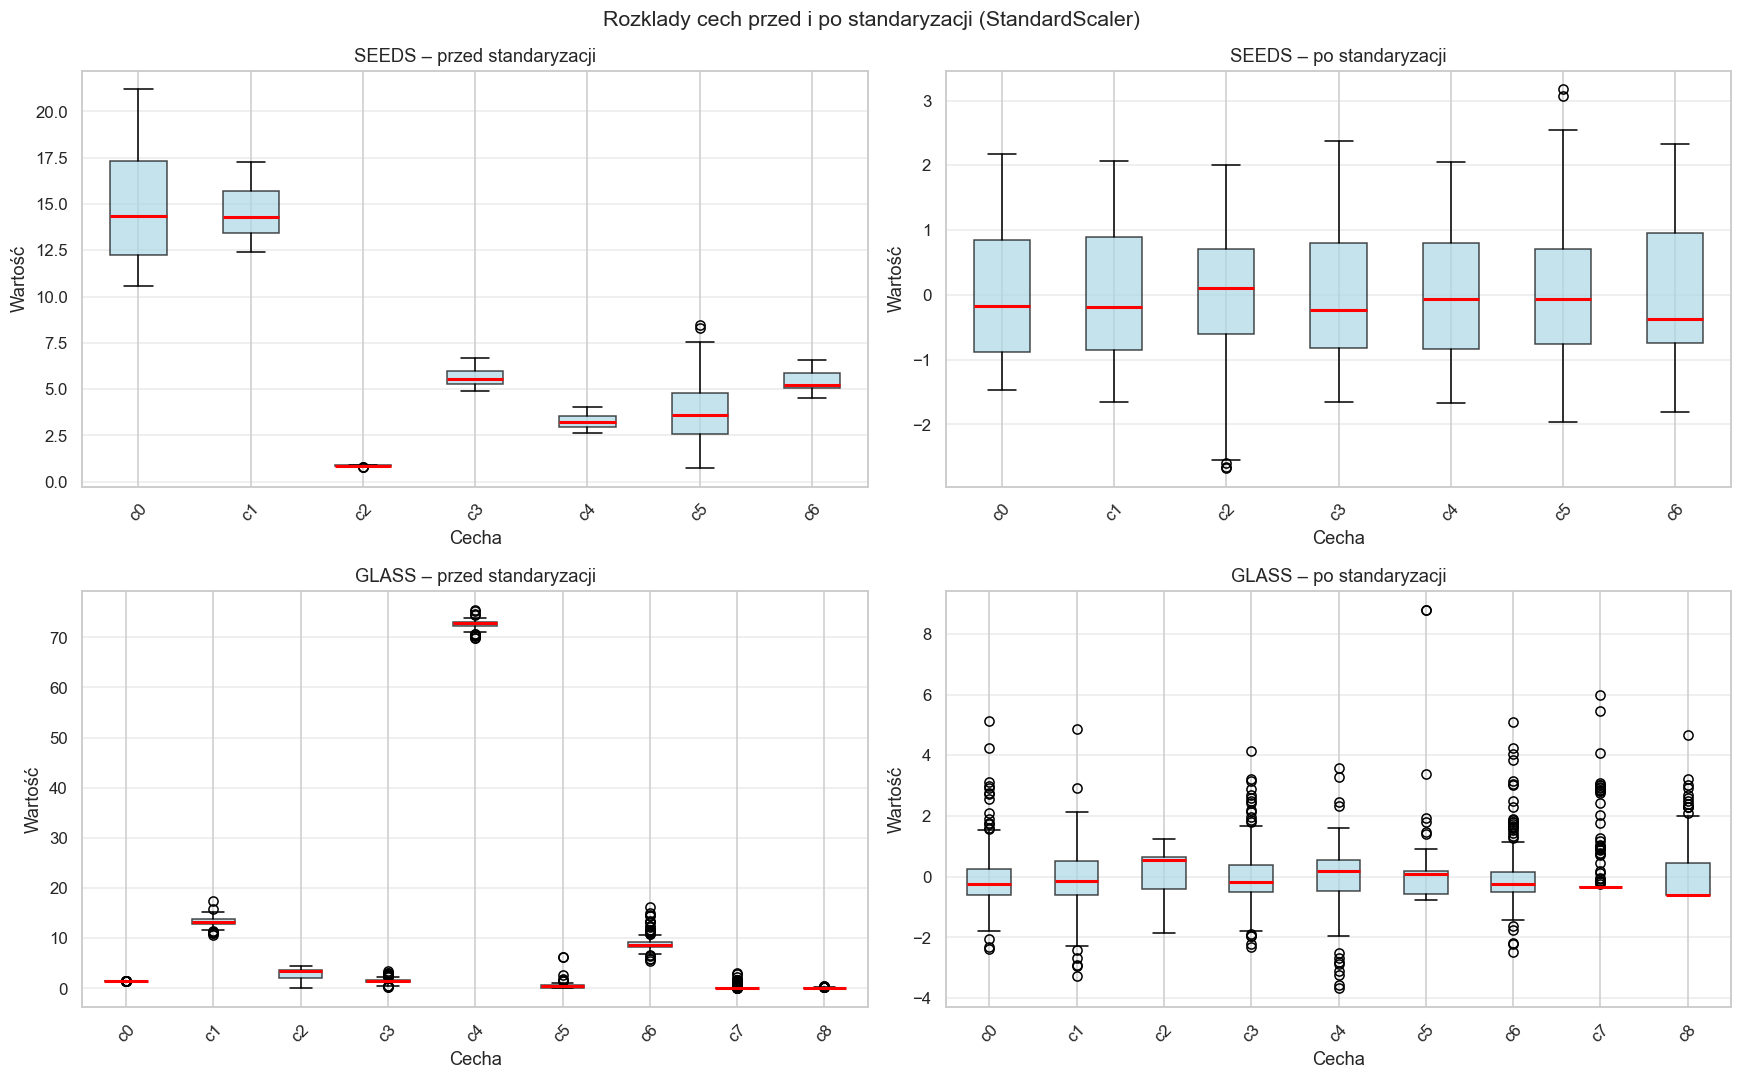

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Rozklady cech przed i po standaryzacji (StandardScaler)', fontsize=14)

for row_idx, (name, X) in enumerate([('SEEDS', X_seeds_raw), ('GLASS', X_glass_raw)]):
    scaler  = StandardScaler()
    X_sc    = scaler.fit_transform(X)
    n_feat  = X.shape[1]
    labels  = [f'c{i}' for i in range(n_feat)]

    for col_idx, (data, suffix) in enumerate([(X, 'przed'), (X_sc, 'po')]):
        ax = axes[row_idx, col_idx]
        ax.boxplot(data, labels=labels, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', lw=2))
        ax.set_title(f'{name} – {suffix} standaryzacji')
        ax.set_xlabel('Cecha'); ax.set_ylabel('Wartość')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig('01_normalization.png', bbox_inches='tight')
plt.show()

In [32]:
scaler_iris  = StandardScaler(); X_iris  = scaler_iris.fit_transform(X_iris_raw)
scaler_seeds = StandardScaler(); X_seeds = scaler_seeds.fit_transform(X_seeds_raw)
scaler_glass = StandardScaler(); X_glass = scaler_glass.fit_transform(X_glass_raw)

pca_iris  = PCA(n_components=2, random_state=SEED).fit(X_iris)
pca_seeds = PCA(n_components=2, random_state=SEED).fit(X_seeds)
pca_glass = PCA(n_components=2, random_state=SEED).fit(X_glass)

for name, pca in [('IRIS', pca_iris), ('SEEDS', pca_seeds), ('GLASS', pca_glass)]:
    var = pca.explained_variance_ratio_
    print(f"  {name}: PC1={var[0]:.1%}  PC2={var[1]:.1%}  Lacznie={sum(var):.1%}")

  IRIS: PC1=73.0%  PC2=22.9%  Lacznie=95.8%
  SEEDS: PC1=71.9%  PC2=17.1%  Lacznie=89.0%
  GLASS: PC1=27.9%  PC2=22.8%  Lacznie=50.7%


### 1.3 Pairplot IRIS

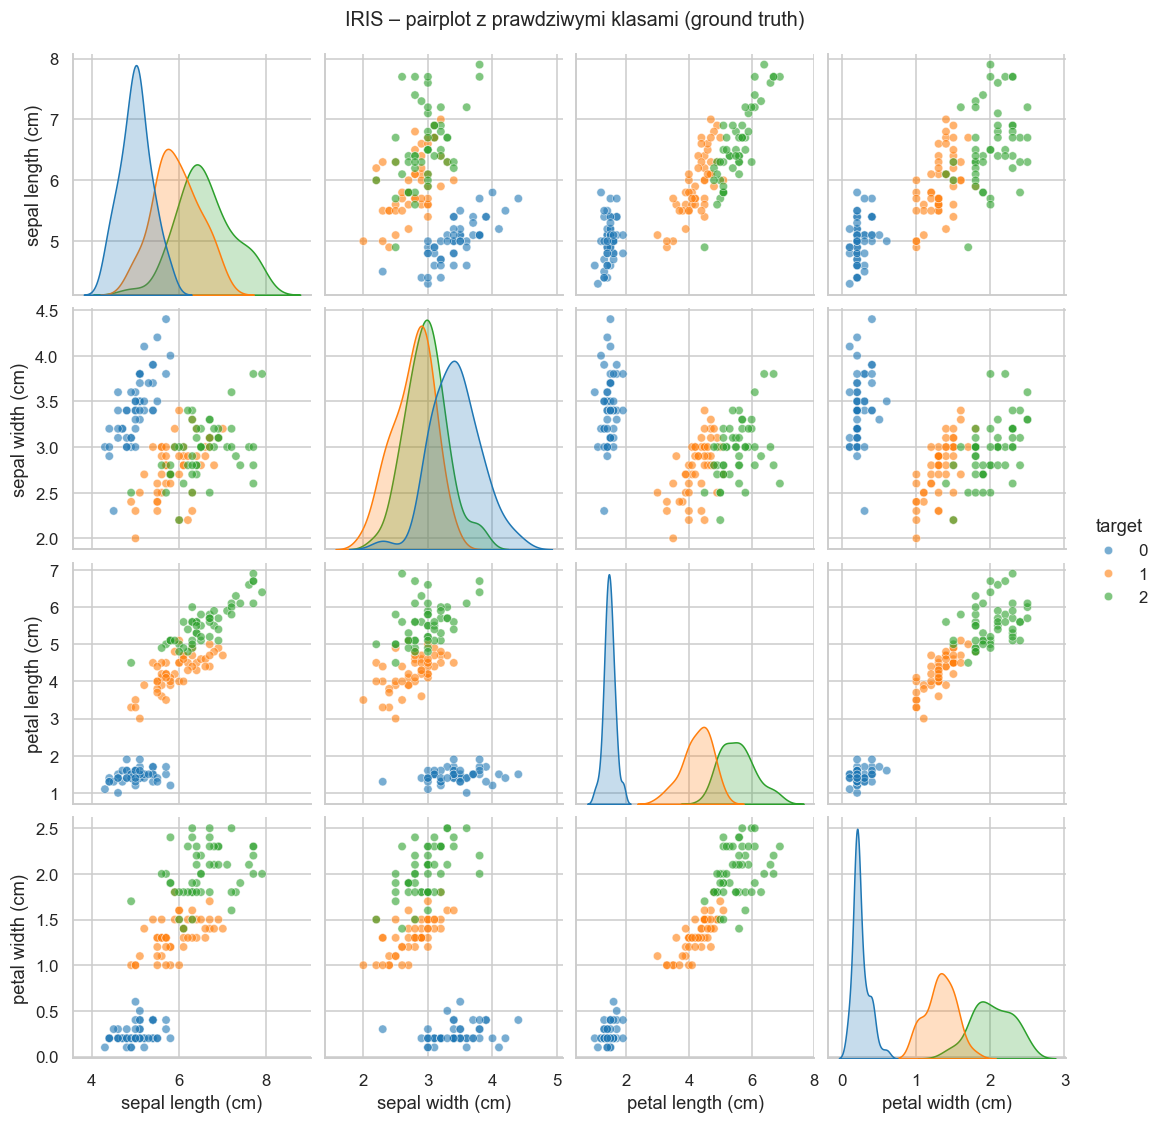

In [9]:
g = sns.pairplot(df_iris, hue='target', palette='tab10',
                 plot_kws={'alpha': 0.6, 's': 30}, diag_kind='kde')
g.figure.suptitle('IRIS – pairplot z prawdziwymi klasami (ground truth)', y=1.02, fontsize=13)
plt.savefig('02_iris_pairplot.png', bbox_inches='tight')
plt.show()

### 1.4 Sanity check – k-means na IRIS (k=3)

IRIS k=3:  ARI=0.620  Purity=0.833  Silhouette=0.460  DBI=0.834


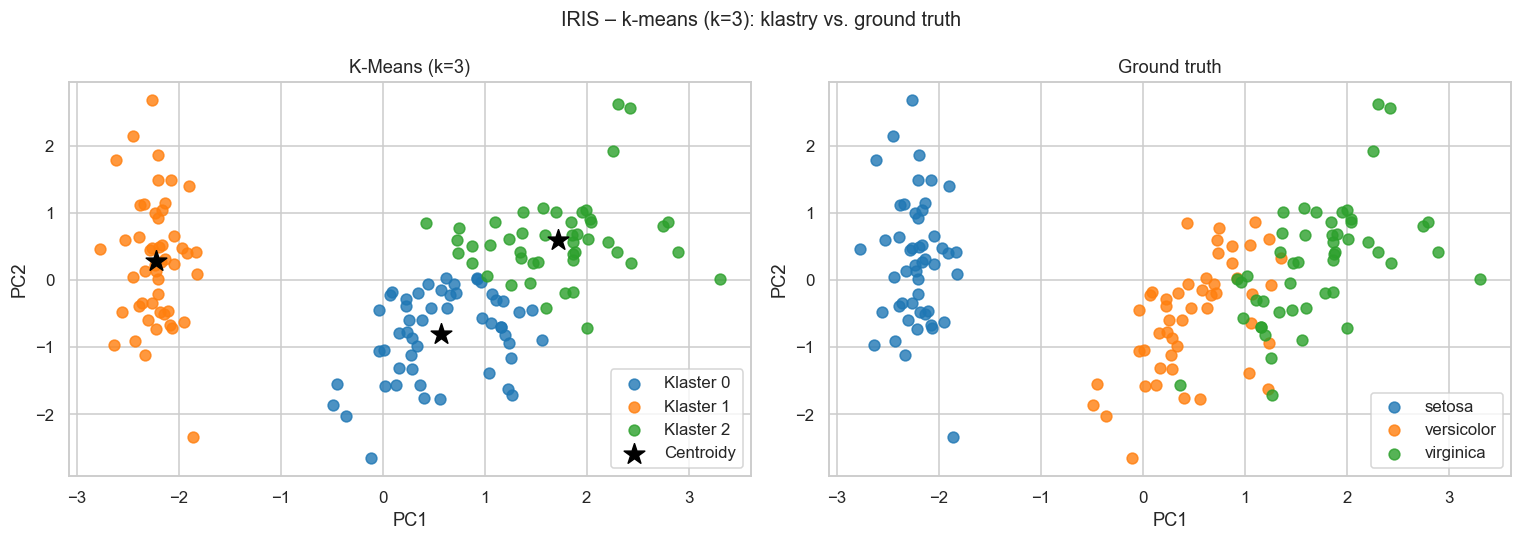

In [11]:
km_iris    = KMeans(n_clusters=3, n_init=20, random_state=SEED)
labels_iris = km_iris.fit_predict(X_iris)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('IRIS – k-means (k=3): klastry vs. ground truth', fontsize=13)

X_iris_2d = pca_iris.transform(X_iris)
palette3   = sns.color_palette('tab10', 3)

for lbl in range(3):
    mask = labels_iris == lbl
    axes[0].scatter(X_iris_2d[mask, 0], X_iris_2d[mask, 1],
                    c=[palette3[lbl]], s=50, alpha=0.8, label=f'Klaster {lbl}')
centers_2d = pca_iris.transform(km_iris.cluster_centers_)
axes[0].scatter(centers_2d[:, 0], centers_2d[:, 1],
                c='black', s=200, marker='*', zorder=5, label='Centroidy')
axes[0].set_title('K-Means (k=3)'); axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

for cls in range(3):
    mask = y_iris == cls
    axes[1].scatter(X_iris_2d[mask, 0], X_iris_2d[mask, 1],
                    c=[palette3[cls]], s=50, alpha=0.8, label=iris.target_names[cls])
axes[1].set_title('Ground truth'); axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend()

ari = adjusted_rand_score(y_iris, labels_iris)
sil = silhouette_score(X_iris, labels_iris)
dbi = davies_bouldin_score(X_iris, labels_iris)
pur = purity_score(y_iris, labels_iris)
print(f"IRIS k=3:  ARI={ari:.3f}  Purity={pur:.3f}  Silhouette={sil:.3f}  DBI={dbi:.3f}")

plt.tight_layout()
plt.show()

### 2a – Wpływ `n_clusters`


In [12]:
k_range = range(2, 12)
results_km = {}

for ds_name, X, y in [('SEEDS', X_seeds, y_seeds), ('GLASS', X_glass, y_glass)]:
    inertias, sils, dbis, aris, purs = [], [], [], [], []
    for k in k_range:
        km     = KMeans(n_clusters=k, n_init=20, max_iter=300, random_state=SEED)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(X, labels))
        dbis.append(davies_bouldin_score(X, labels))
        aris.append(adjusted_rand_score(y, labels))
        purs.append(purity_score(y, labels))
    results_km[ds_name] = dict(inertia=inertias, silhouette=sils,
                                dbi=dbis, ari=aris, purity=purs)
    print(f"{ds_name} – obliczono dla k={list(k_range)}")

SEEDS – obliczono dla k=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
GLASS – obliczono dla k=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


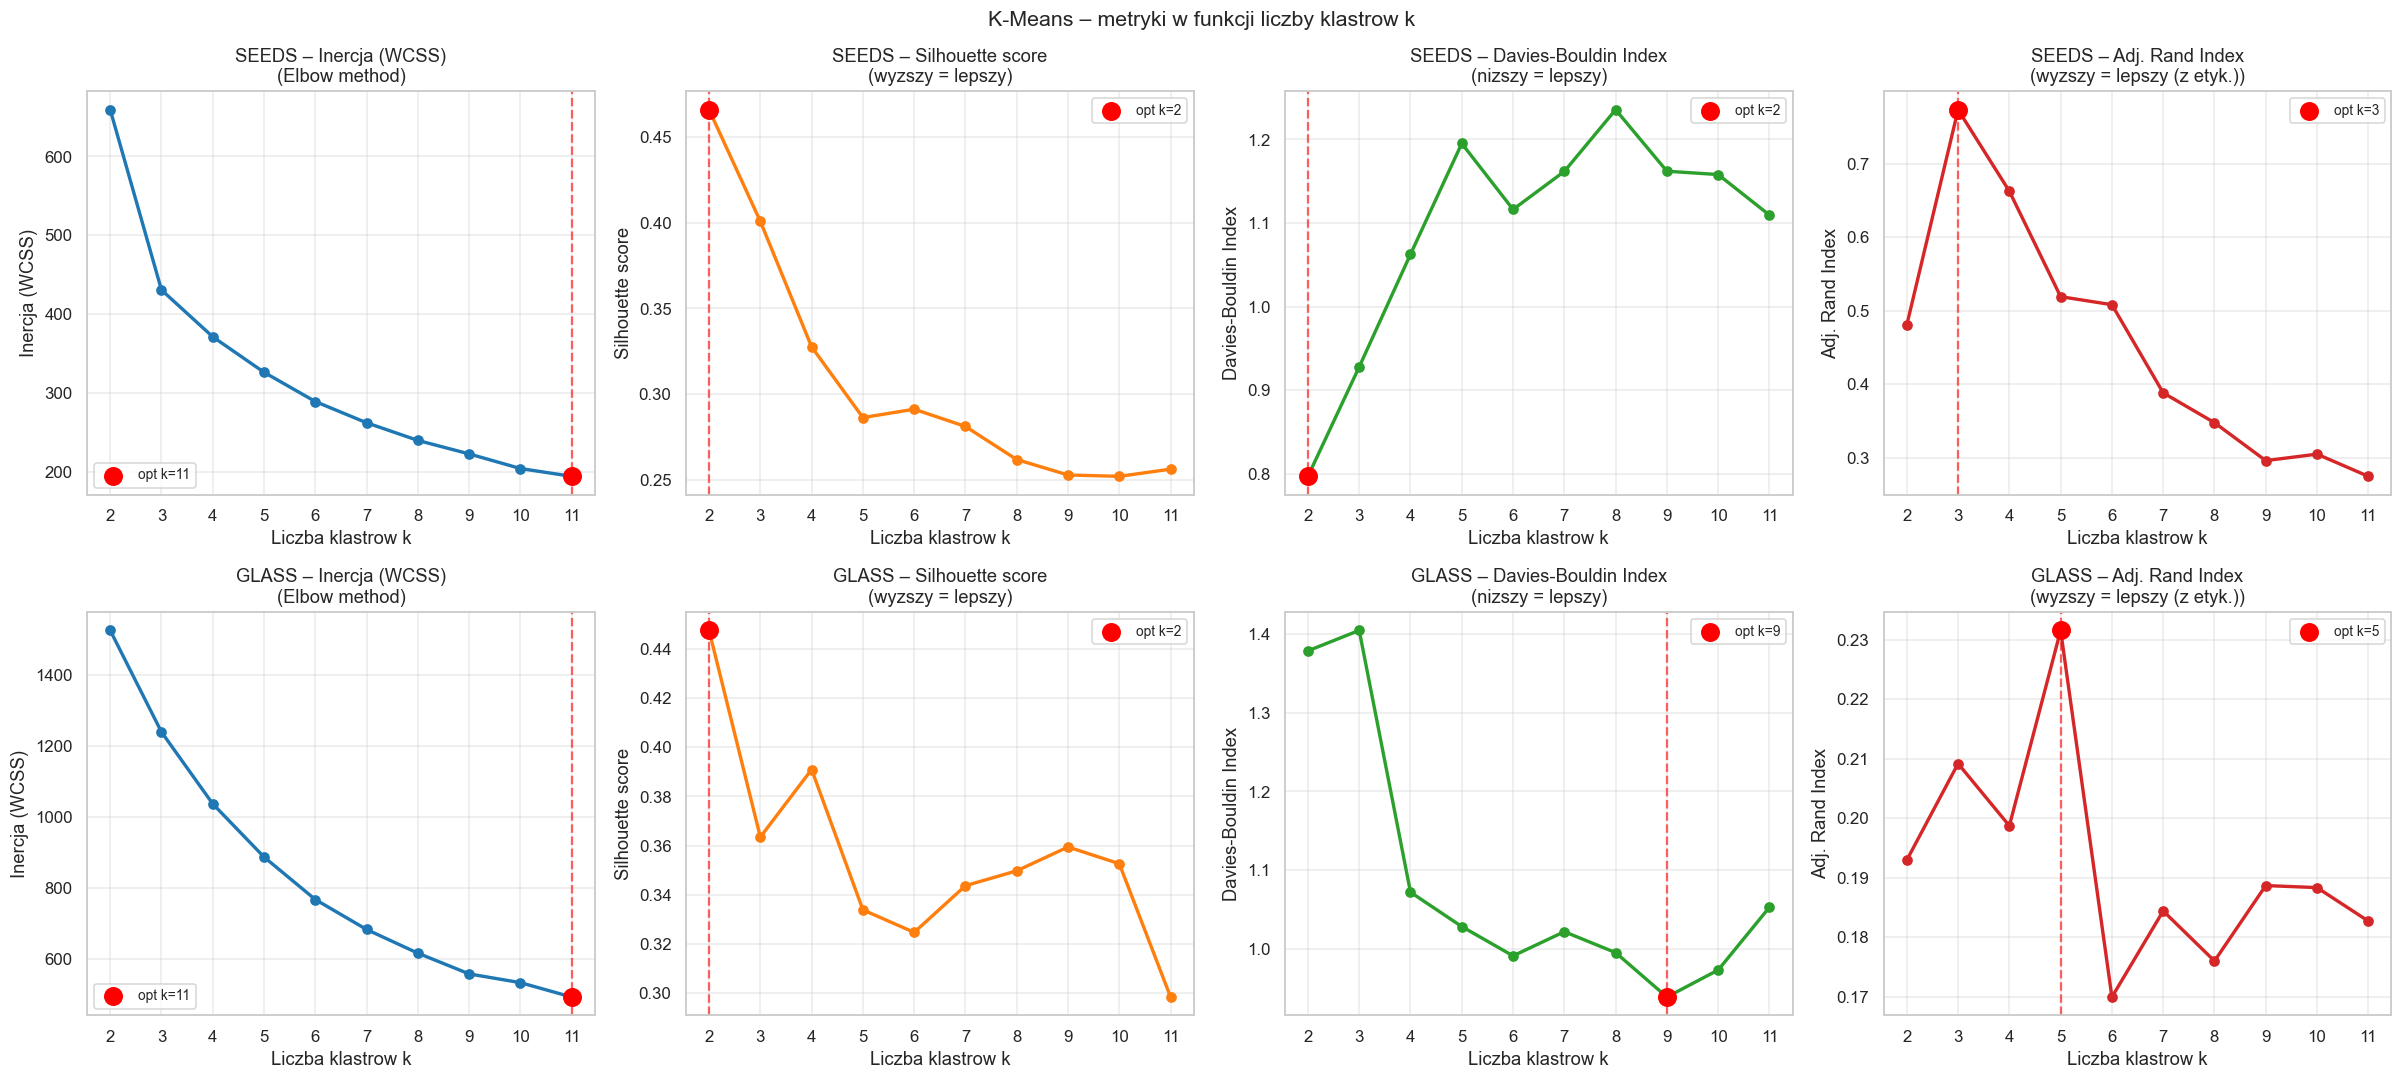

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('K-Means – metryki w funkcji liczby klastrow k', fontsize=14)

metrics_def = [
    ('inertia',    'Inercja (WCSS)',       False, 'Elbow method'),
    ('silhouette', 'Silhouette score',     True,  'wyzszy = lepszy'),
    ('dbi',        'Davies-Bouldin Index', False, 'nizszy = lepszy'),
    ('ari',        'Adj. Rand Index',      True,  'wyzszy = lepszy (z etyk.)'),
]

for col, (key, ylabel, maximize, note) in enumerate(metrics_def):
    for row, ds_name in enumerate(['SEEDS', 'GLASS']):
        ax   = axes[row, col]
        vals = results_km[ds_name][key]
        ks   = list(k_range)

        ax.plot(ks, vals, 'o-', lw=2.2, markersize=6, color=f'C{col}')

        best_idx = int(np.argmax(vals)) if maximize else int(np.argmin(vals))
        best_k   = ks[best_idx]
        best_v   = vals[best_idx]
        ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.6, lw=1.5)
        ax.scatter([best_k], [best_v], s=130, zorder=5, color='red',
                   label=f'opt k={best_k}')

        ax.set_xlabel('Liczba klastrow k')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ds_name} – {ylabel}\n({note})')
        ax.set_xticks(ks)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

#### Siatka wizualizacji klastrów PCA 2D dla różnych k (SEEDS)

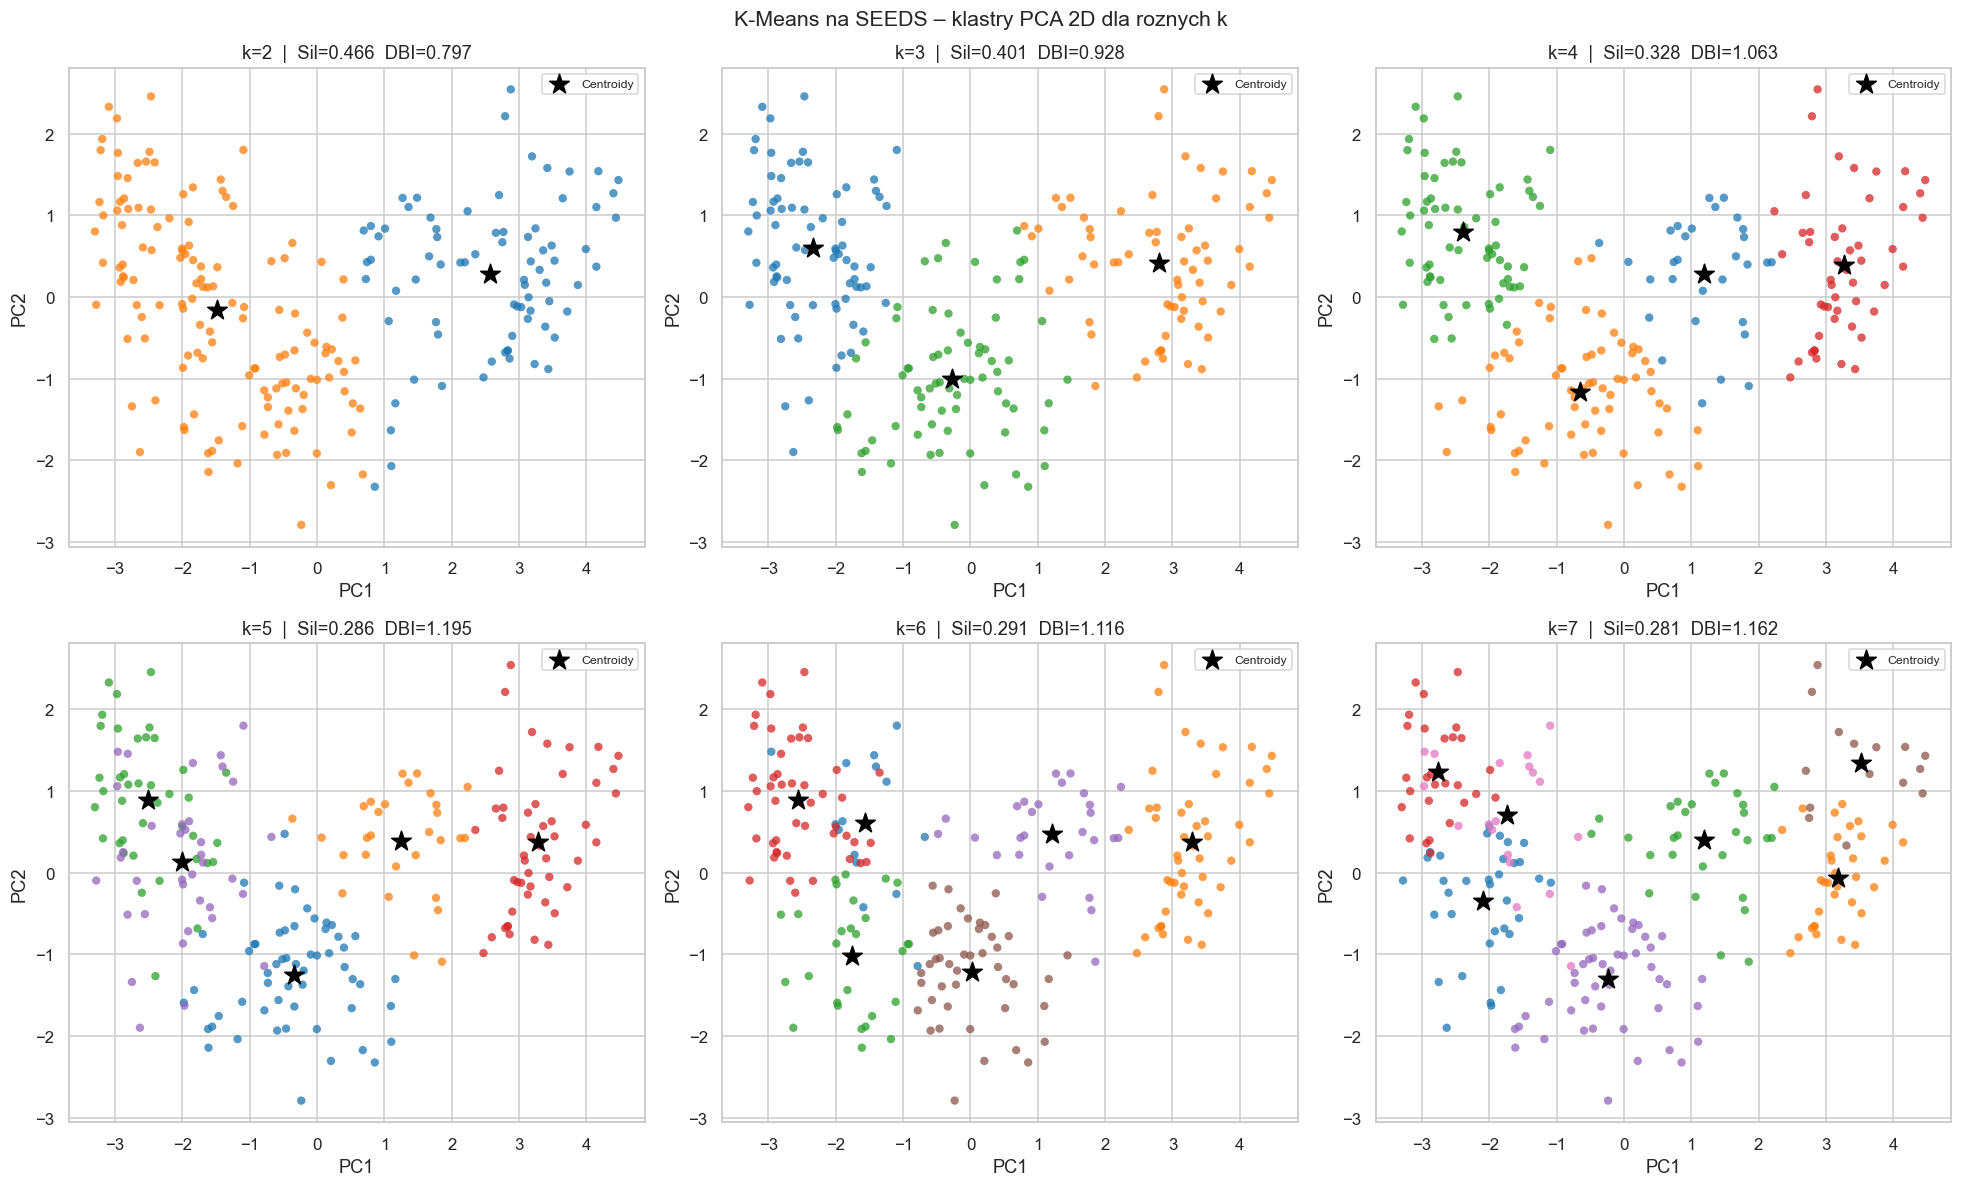

In [14]:
k_vals_grid = [2, 3, 4, 5, 6, 7]
fig, axes   = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('K-Means na SEEDS – klastry PCA 2D dla roznych k', fontsize=14)

X_s2d = pca_seeds.transform(X_seeds)

for idx, k in enumerate(k_vals_grid):
    ax     = axes[idx // 3][idx % 3]
    km     = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    labels = km.fit_predict(X_seeds)
    pal    = sns.color_palette('tab10', k)

    for lbl in range(k):
        mask = labels == lbl
        ax.scatter(X_s2d[mask, 0], X_s2d[mask, 1],
                   c=[pal[lbl]], s=30, alpha=0.75, edgecolors='none')

    centers_2d = pca_seeds.transform(km.cluster_centers_)
    ax.scatter(centers_2d[:, 0], centers_2d[:, 1],
               c='black', s=180, marker='*', zorder=5, label='Centroidy')

    sil = silhouette_score(X_seeds, labels)
    dbi = davies_bouldin_score(X_seeds, labels)
    ax.set_title(f'k={k}  |  Sil={sil:.3f}  DBI={dbi:.3f}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 2b – Wpływ liczby restartów `n_init`

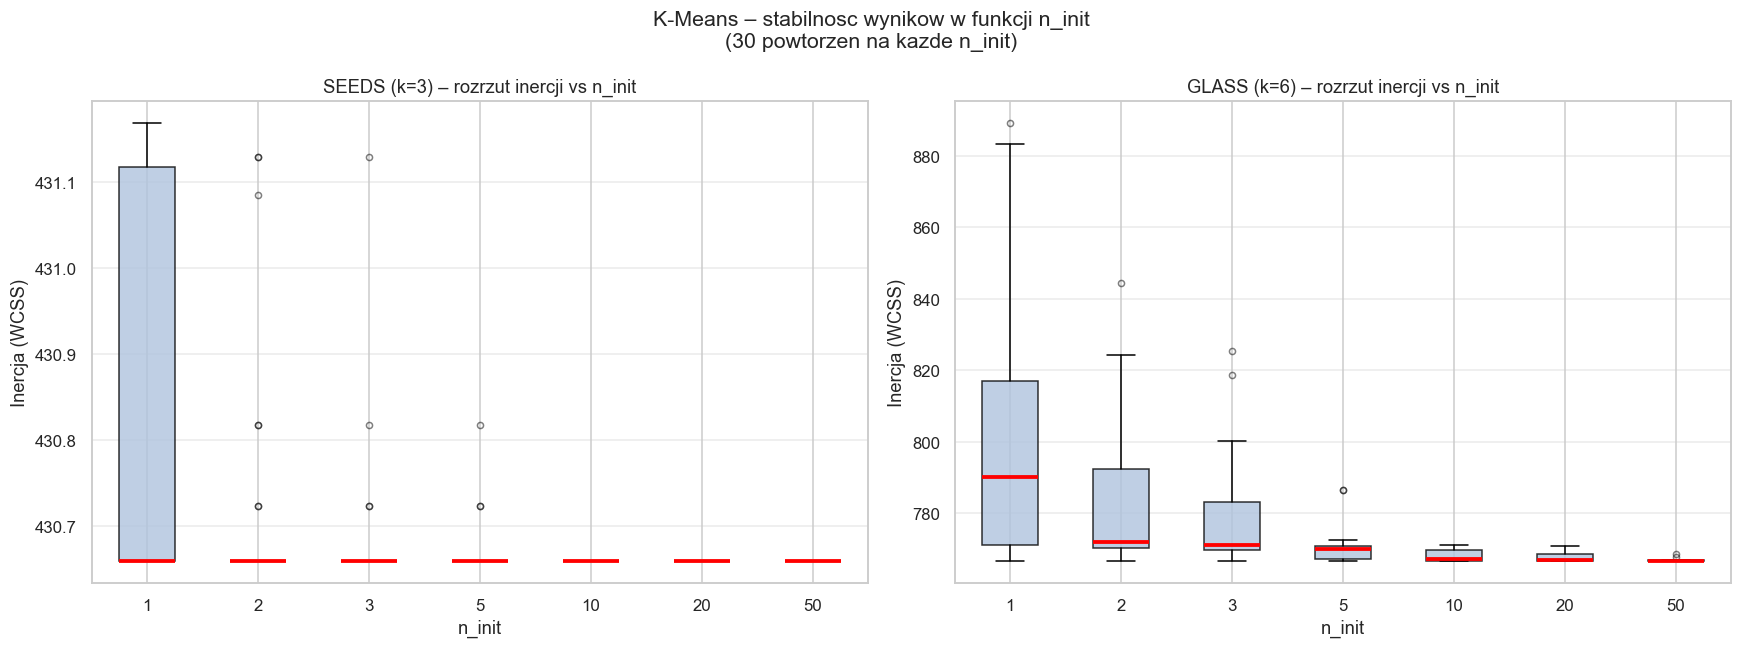

In [15]:
n_init_values = [1, 2, 3, 5, 10, 20, 50]
N_REPEATS     = 30

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-Means – stabilnosc wynikow w funkcji n_init\n'
             f'({N_REPEATS} powtorzen na kazde n_init)', fontsize=14)

for ax, (ds_name, X, k_opt) in zip(axes, [('SEEDS', X_seeds, 3),
                                            ('GLASS', X_glass, 6)]):
    all_inertias = []
    for n_init in n_init_values:
        run_inertias = [
            KMeans(n_clusters=k_opt, n_init=n_init, random_state=rep).fit(X).inertia_
            for rep in range(N_REPEATS)
        ]
        all_inertias.append(run_inertias)

    bp = ax.boxplot(all_inertias, positions=range(len(n_init_values)),
                    patch_artist=True, widths=0.5,
                    medianprops=dict(color='red', lw=2.5),
                    flierprops=dict(marker='o', markersize=4, alpha=0.5))
    for patch in bp['boxes']:
        patch.set_facecolor('lightsteelblue'); patch.set_alpha(0.8)

    ax.set_xticks(range(len(n_init_values)))
    ax.set_xticklabels([str(n) for n in n_init_values])
    ax.set_xlabel('n_init'); ax.set_ylabel('Inercja (WCSS)')
    ax.set_title(f'{ds_name} (k={k_opt}) – rozrzut inercji vs n_init')
    ax.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

### 2d – Heatmapa Silhouette: n_clusters × n_init

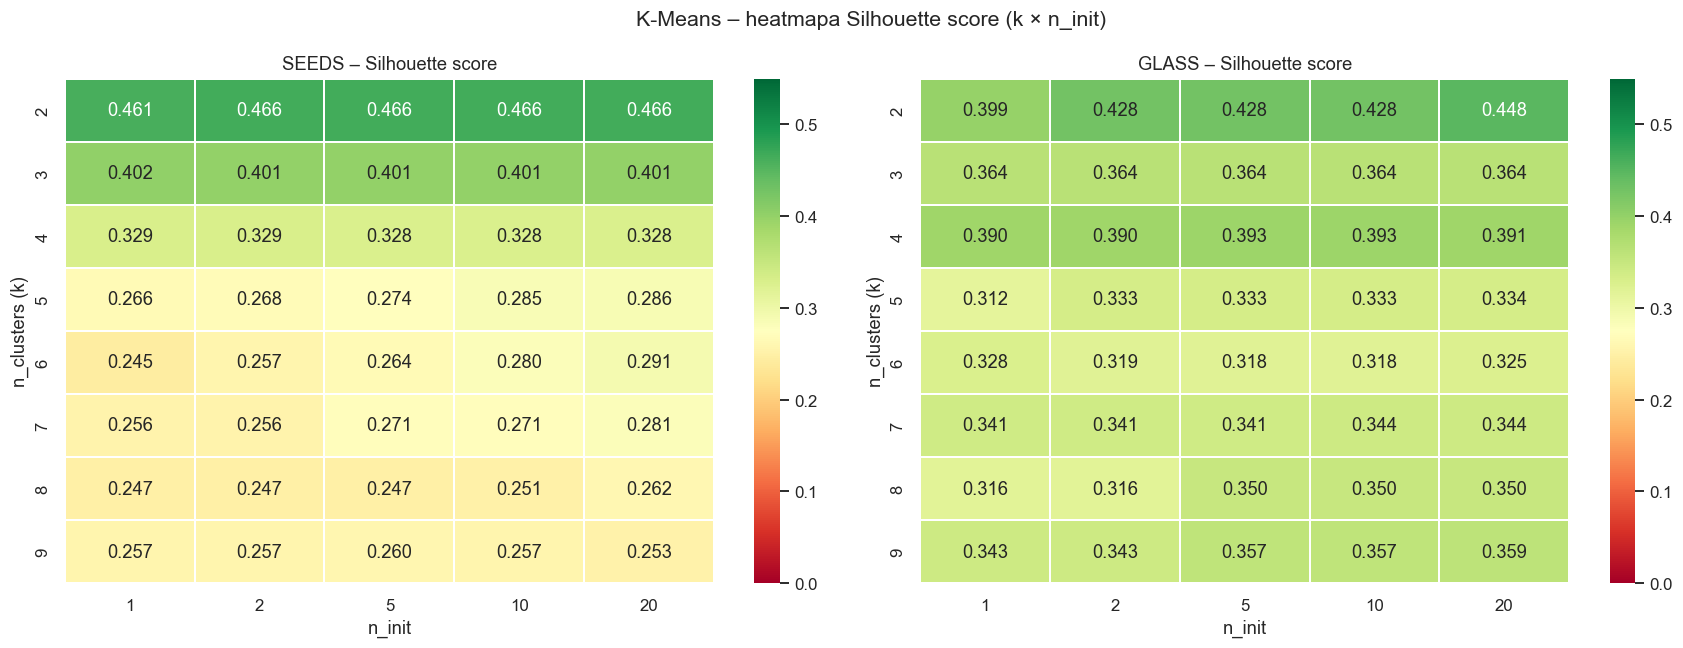

In [18]:
k_h      = list(range(2, 10))
ninit_h  = [1, 2, 5, 10, 20]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-Means – heatmapa Silhouette score (k × n_init)', fontsize=14)

for ax, (ds_name, X) in zip(axes, [('SEEDS', X_seeds), ('GLASS', X_glass)]):
    matrix = np.zeros((len(k_h), len(ninit_h)))
    for i, k in enumerate(k_h):
        for j, ni in enumerate(ninit_h):
            km = KMeans(n_clusters=k, n_init=ni, random_state=SEED)
            matrix[i, j] = silhouette_score(X, km.fit_predict(X))

    sns.heatmap(matrix, annot=True, fmt='.3f', cmap='RdYlGn',
                xticklabels=ninit_h, yticklabels=k_h,
                ax=ax, vmin=0, vmax=0.55, linewidths=0.3)
    ax.set_xlabel('n_init'); ax.set_ylabel('n_clusters (k)')
    ax.set_title(f'{ds_name} – Silhouette score')

plt.tight_layout()
plt.show()

### 2e – Metryki z etykietami: ARI, Purity + Per-sample Silhouette + Contingency Matrix

SEEDS k=3: ARI=0.773  Purity=0.919  Silhouette=0.401  DBI=0.928
GLASS k=6: ARI=0.170  Purity=0.542  Silhouette=0.325  DBI=0.991


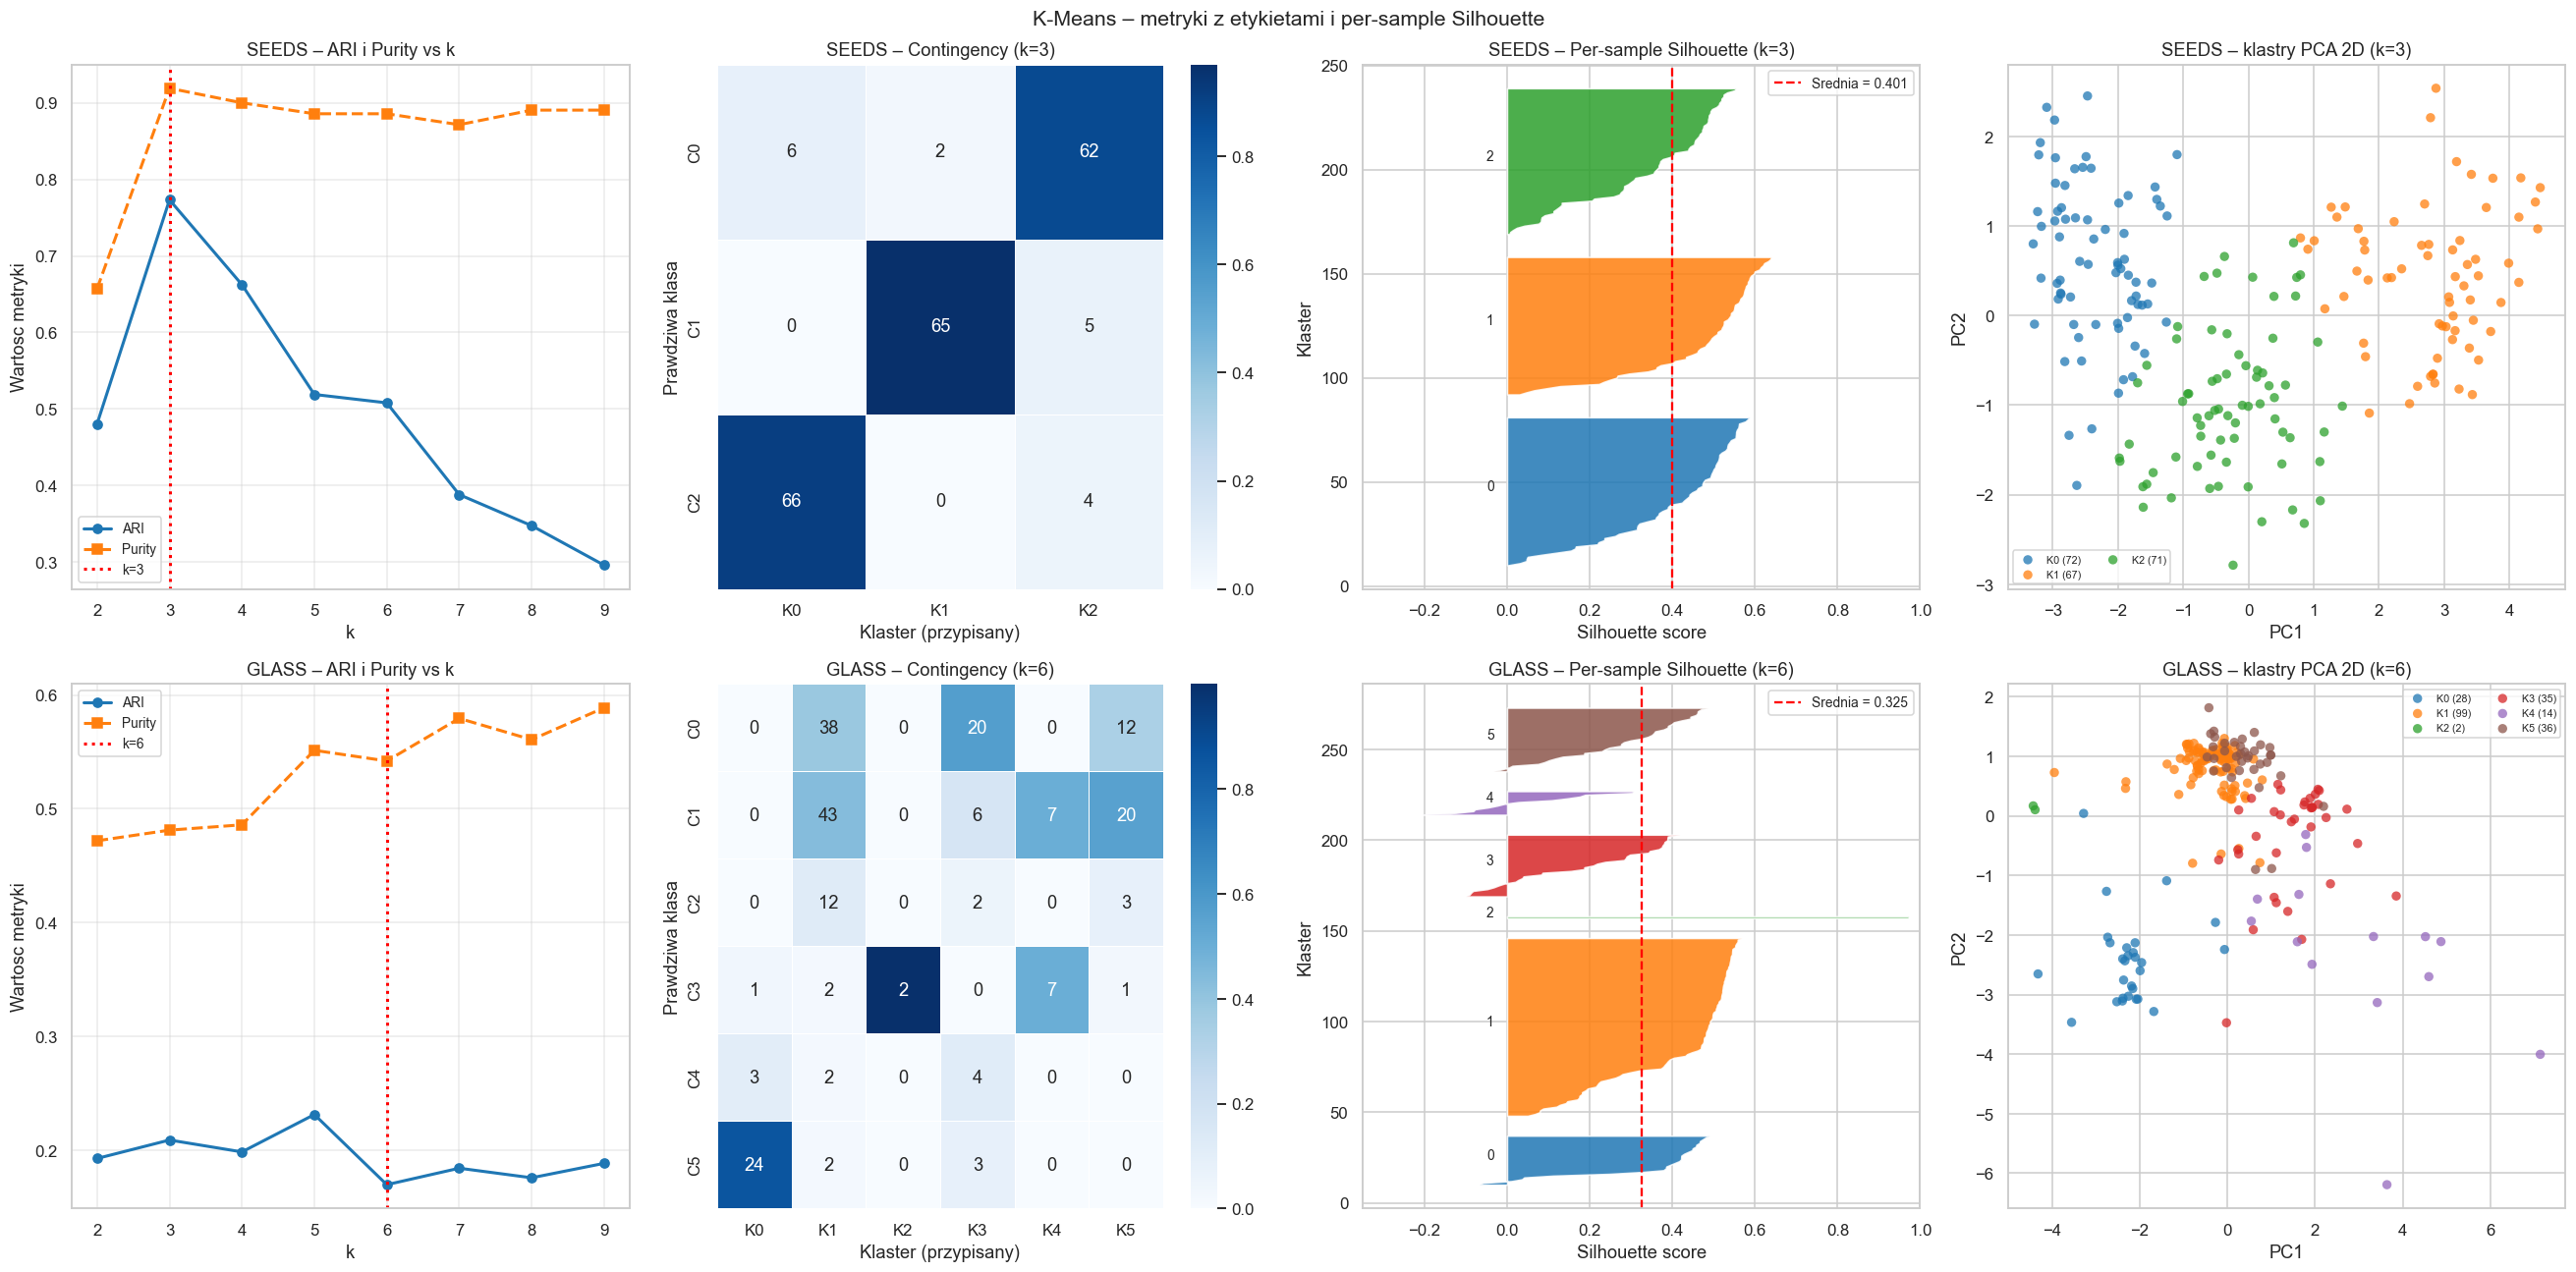

In [19]:
optimal_k = {'SEEDS': 3, 'GLASS': 6}

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
fig.suptitle('K-Means – metryki z etykietami i per-sample Silhouette', fontsize=14)

for row, (ds_name, X, y) in enumerate([('SEEDS', X_seeds, y_seeds),
                                         ('GLASS', X_glass, y_glass)]):
    k_opt  = optimal_k[ds_name]
    k_rng  = range(2, 10)
    pca_o  = pca_seeds if ds_name == 'SEEDS' else pca_glass

    # ARI i Purity vs k
    aris, purs = [], []
    for k in k_rng:
        lbl = KMeans(n_clusters=k, n_init=20, random_state=SEED).fit_predict(X)
        aris.append(adjusted_rand_score(y, lbl))
        purs.append(purity_score(y, lbl))

    ax = axes[row, 0]
    ax.plot(list(k_rng), aris, 'o-', label='ARI',    lw=2, color='C0')
    ax.plot(list(k_rng), purs, 's--', label='Purity', lw=2, color='C1')
    ax.axvline(x=k_opt, color='red', linestyle=':', lw=2, label=f'k={k_opt}')
    ax.set_xlabel('k'); ax.set_ylabel('Wartosc metryki')
    ax.set_title(f'{ds_name} – ARI i Purity vs k')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.4)

    # Najlepsza konfiguracja
    labels_best = KMeans(n_clusters=k_opt, n_init=20, random_state=SEED).fit_predict(X)

    # Contingency matrix
    plot_contingency_heatmap(y, labels_best, axes[row, 1],
                              title=f'{ds_name} – Contingency (k={k_opt})')

    # Per-sample Silhouette diagram
    plot_silhouette_diagram(X, labels_best, axes[row, 2],
                             title=f'{ds_name} – Per-sample Silhouette (k={k_opt})')

    # PCA 2D
    plot_pca_clusters(X, labels_best, axes[row, 3], pca_o,
                      title=f'{ds_name} – klastry PCA 2D (k={k_opt})')

    ari_v = adjusted_rand_score(y, labels_best)
    pur_v = purity_score(y, labels_best)
    sil_v = silhouette_score(X, labels_best)
    dbi_v = davies_bouldin_score(X, labels_best)
    print(f"{ds_name} k={k_opt}: ARI={ari_v:.3f}  Purity={pur_v:.3f}  "
          f"Silhouette={sil_v:.3f}  DBI={dbi_v:.3f}")

plt.tight_layout()
plt.show()

---
## Algorytm DBSCAN


### 3a – Wpływ `eps`

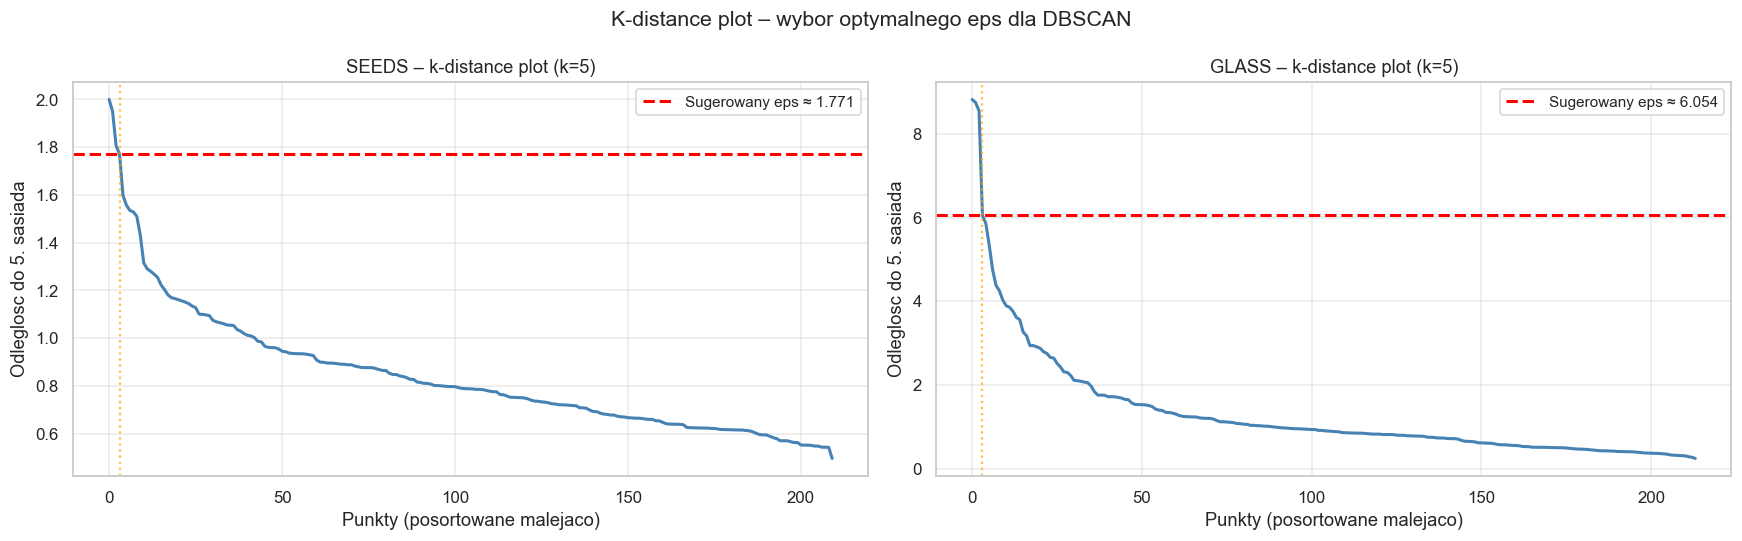

In [20]:
min_samples_ref = 5

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('K-distance plot – wybor optymalnego eps dla DBSCAN', fontsize=14)

for ax, (ds_name, X) in zip(axes, [('SEEDS', X_seeds), ('GLASS', X_glass)]):
    nbrs       = NearestNeighbors(n_neighbors=min_samples_ref).fit(X)
    distances, _ = nbrs.kneighbors(X)
    k_dists    = np.sort(distances[:, -1])[::-1]

    ax.plot(range(len(k_dists)), k_dists, lw=2, color='steelblue')
    ax.set_xlabel('Punkty (posortowane malejaco)')
    ax.set_ylabel(f'Odleglosc do {min_samples_ref}. sasiada')
    ax.set_title(f'{ds_name} – k-distance plot (k={min_samples_ref})')
    ax.grid(True, alpha=0.4)

    # Automatyczne wykrycie "lokcia"
    d2    = np.diff(np.diff(k_dists))
    elbow = int(np.argmax(np.abs(d2))) + 1
    eps_s = k_dists[elbow]
    ax.axhline(y=eps_s, color='red', linestyle='--', lw=2,
               label=f'Sugerowany eps ≈ {eps_s:.3f}')
    ax.axvline(x=elbow, color='orange', linestyle=':', lw=1.5, alpha=0.7)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

#### Wizualizacja geometryczna: core / border / noise + okrąg eps


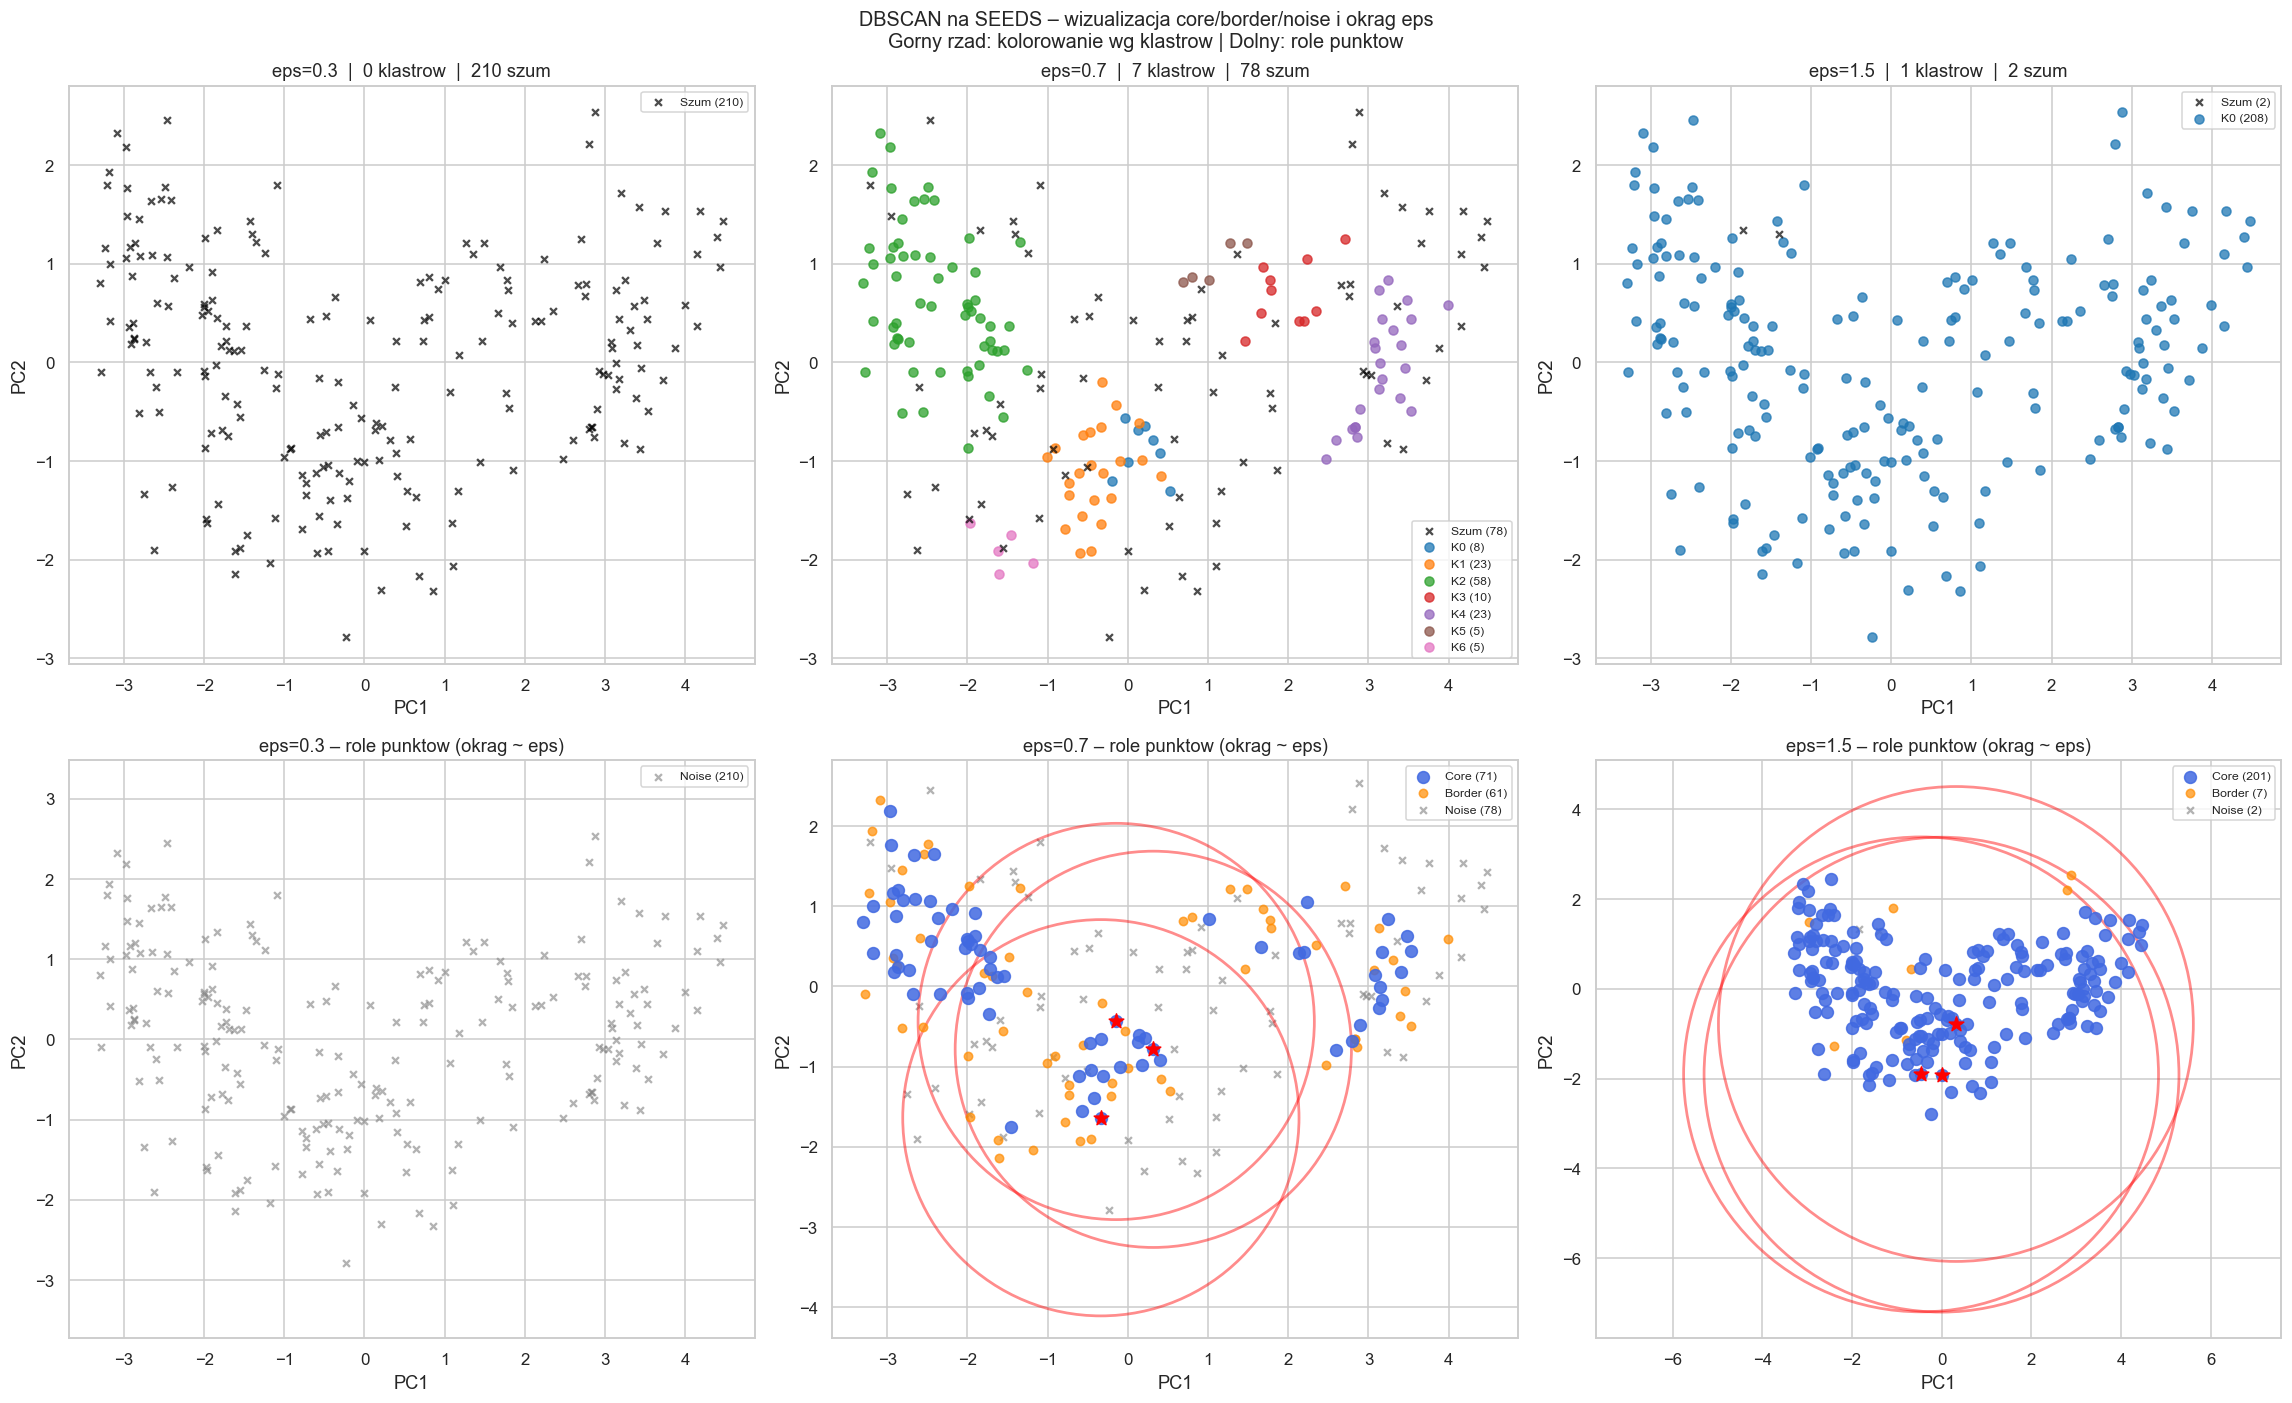

In [ ]:
eps_vals_geo = [0.3, 0.7, 1.5]   
min_s_geo    = 5

pca_geo = PCA(n_components=2, random_state=SEED).fit(X_seeds)
X_geo2d = pca_geo.transform(X_seeds)
scale   = np.std(X_geo2d) / np.std(X_seeds)  

fig, axes = plt.subplots(2, 3, figsize=(21, 13))
fig.suptitle('DBSCAN na SEEDS – wizualizacja core/border/noise i okrag eps\n'
             'Gorny rzad: kolorowanie wg klastrow | Dolny: role punktow', fontsize=13)

for col, eps in enumerate(eps_vals_geo):
    db      = DBSCAN(eps=eps, min_samples=min_s_geo).fit(X_seeds)
    labels  = db.labels_
    c_idx   = db.core_sample_indices_

    n_cl    = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    is_core   = np.zeros(len(X_seeds), dtype=bool); is_core[c_idx] = True
    is_noise  = labels == -1
    is_border = ~is_core & ~is_noise

    pal = sns.color_palette('tab10', max(n_cl, 1))

    ax_top = axes[0, col]
    color_i = 0
    for lbl in sorted(set(labels)):
        mask = labels == lbl
        if lbl == -1:
            ax_top.scatter(X_geo2d[mask, 0], X_geo2d[mask, 1],
                           c='black', s=20, marker='x', alpha=0.7,
                           label=f'Szum ({mask.sum()})', zorder=3)
        else:
            ax_top.scatter(X_geo2d[mask, 0], X_geo2d[mask, 1],
                           c=[pal[color_i % 10]], s=35, alpha=0.75,
                           label=f'K{lbl} ({mask.sum()})')
            color_i += 1
    ax_top.set_title(f'eps={eps}  |  {n_cl} klastrow  |  {n_noise} szum')
    ax_top.set_xlabel('PC1'); ax_top.set_ylabel('PC2')
    ax_top.legend(fontsize=8, loc='best')

    ax_bot = axes[1, col]
    if is_core.any():
        ax_bot.scatter(X_geo2d[is_core, 0], X_geo2d[is_core, 1],
                       c='royalblue', s=60, alpha=0.85,
                       label=f'Core ({is_core.sum()})', zorder=3)
    if is_border.any():
        ax_bot.scatter(X_geo2d[is_border, 0], X_geo2d[is_border, 1],
                       c='darkorange', s=30, alpha=0.7,
                       label=f'Border ({is_border.sum()})', zorder=2)
    if is_noise.any():
        ax_bot.scatter(X_geo2d[is_noise, 0], X_geo2d[is_noise, 1],
                       c='gray', s=20, marker='x', alpha=0.6,
                       label=f'Noise ({is_noise.sum()})', zorder=1)

    eps_2d = eps * scale * 2.0 
    sample_c = c_idx[:min(3, len(c_idx))]
    for ci in sample_c:
        circle = mpatches.Circle(
            (X_geo2d[ci, 0], X_geo2d[ci, 1]),
            eps_2d, fill=False, color='red', alpha=0.45, lw=1.8
        )
        ax_bot.add_patch(circle)
        ax_bot.scatter([X_geo2d[ci, 0]], [X_geo2d[ci, 1]],
                       c='red', s=100, marker='*', zorder=6)

    ax_bot.set_title(f'eps={eps} – role punktow (okrag ~ eps)')
    ax_bot.set_xlabel('PC1'); ax_bot.set_ylabel('PC2')
    ax_bot.legend(fontsize=8, loc='best')
    ax_bot.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()

#### Metryki DBSCAN w funkcji eps (SEEDS i GLASS)

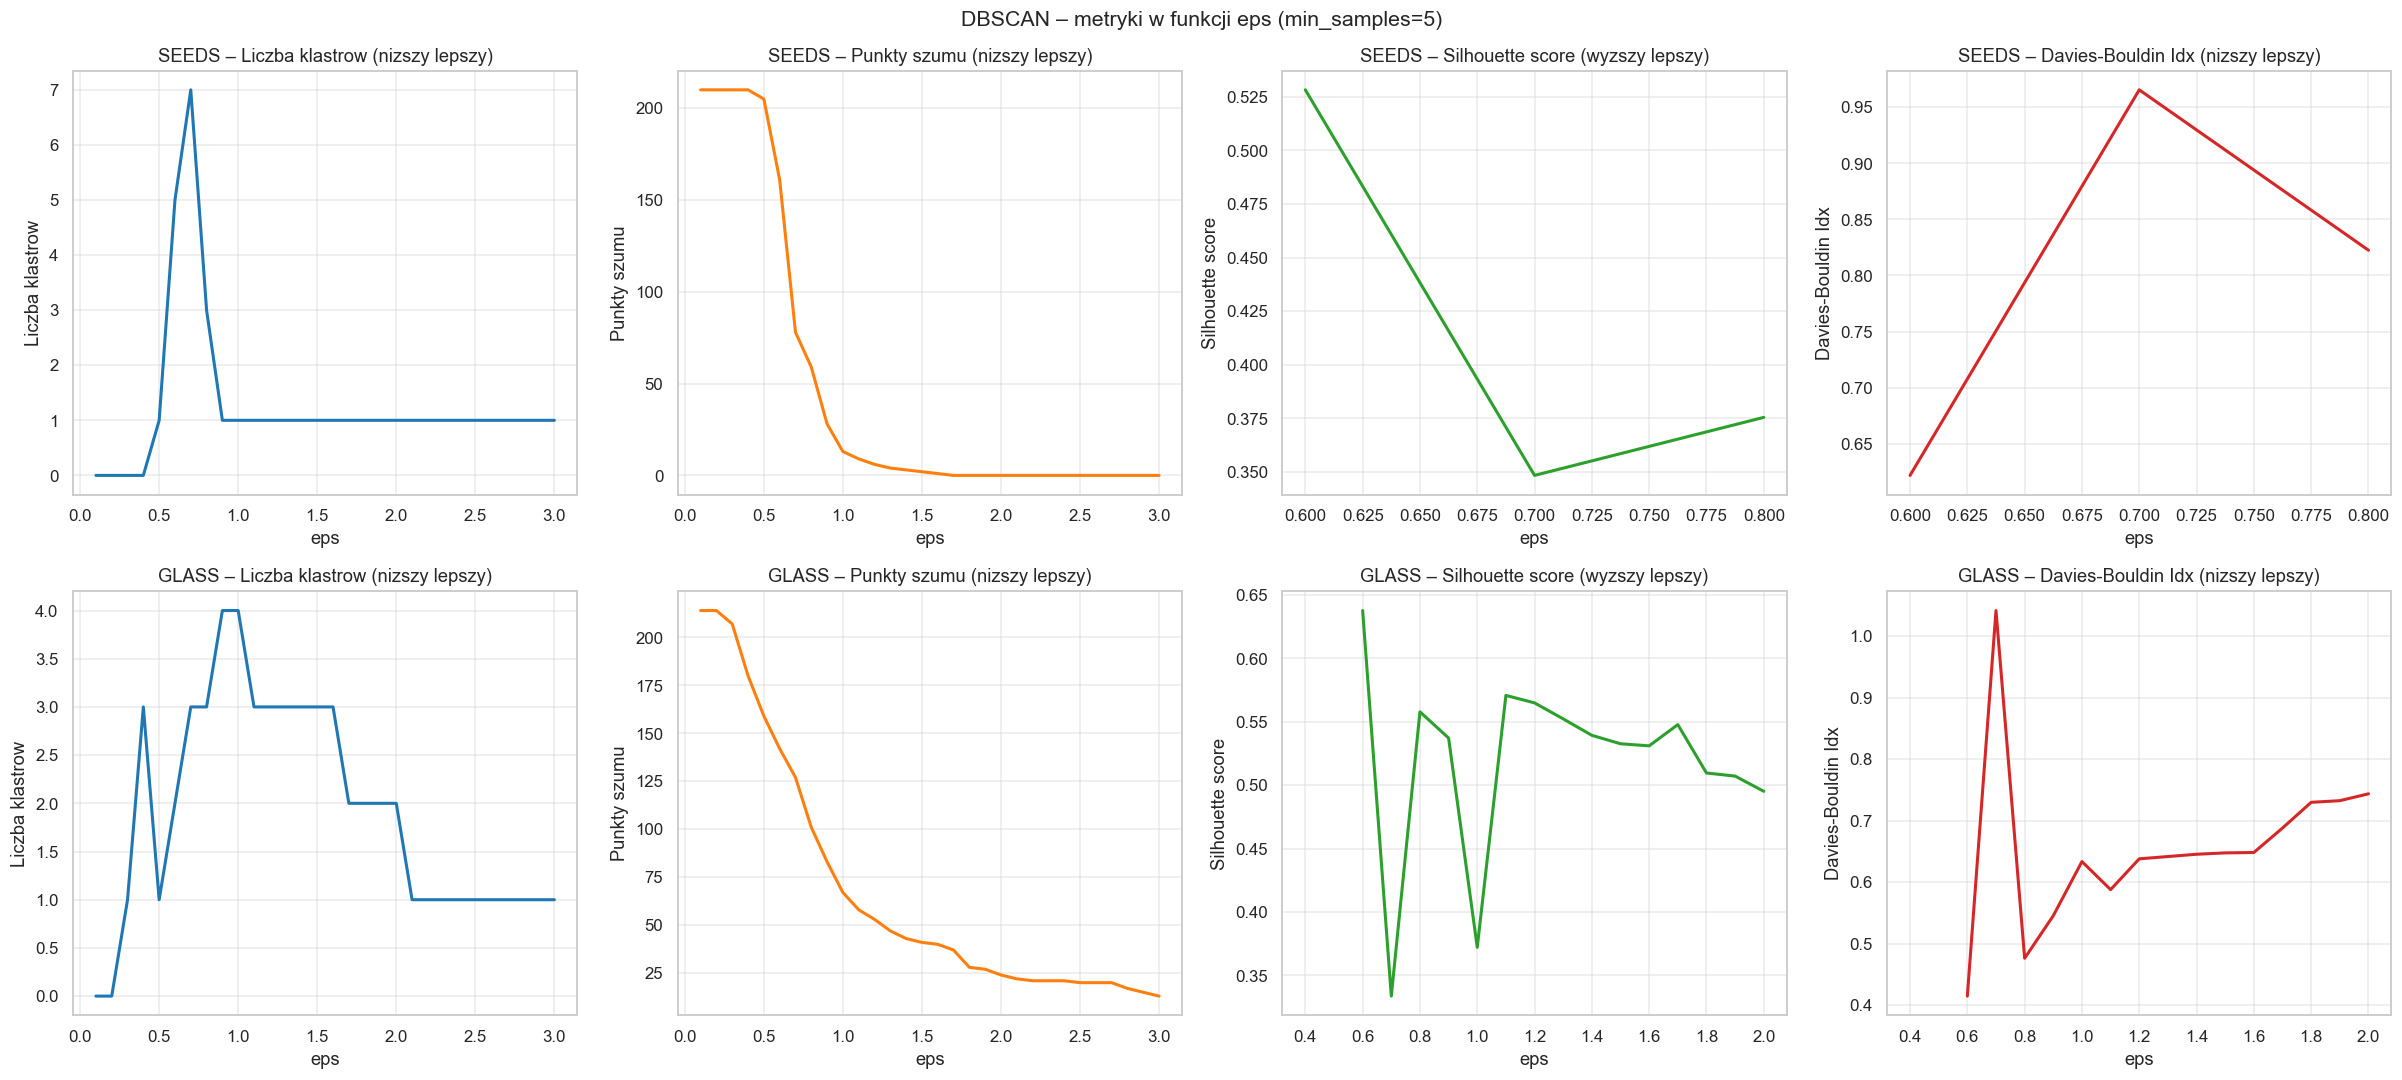

In [22]:
eps_range = np.round(np.arange(0.1, 3.05, 0.1), 2)
min_s     = 5

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('DBSCAN – metryki w funkcji eps (min_samples=5)', fontsize=14)

for row, (ds_name, X, y) in enumerate([('SEEDS', X_seeds, y_seeds),
                                         ('GLASS', X_glass, y_glass)]):
    n_cl_l, noise_l, sil_l, dbi_l = [], [], [], []

    for eps in eps_range:
        db     = DBSCAN(eps=eps, min_samples=min_s).fit(X)
        labels = db.labels_
        n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
        mask   = labels != -1
        n_cl_l.append(n_cl)
        noise_l.append(int((labels == -1).sum()))

        if n_cl >= 2 and mask.sum() > n_cl:
            sil_l.append(silhouette_score(X[mask], labels[mask]))
            dbi_l.append(davies_bouldin_score(X[mask], labels[mask]))
        else:
            sil_l.append(np.nan); dbi_l.append(np.nan)

    plot_def = [
        (n_cl_l,  'Liczba klastrow',    'C0', False),
        (noise_l, 'Punkty szumu',       'C1', False),
        (sil_l,   'Silhouette score',   'C2', True),
        (dbi_l,   'Davies-Bouldin Idx', 'C3', False),
    ]
    for col, (data, label, color, maximize) in enumerate(plot_def):
        ax = axes[row, col]
        ax.plot(eps_range, data, lw=2, color=color)
        ax.set_xlabel('eps'); ax.set_ylabel(label)
        direction = '(wyzszy lepszy)' if maximize else '(nizszy lepszy)'
        ax.set_title(f'{ds_name} – {label} {direction}')
        ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### 3b – Wpływ `min_samples`

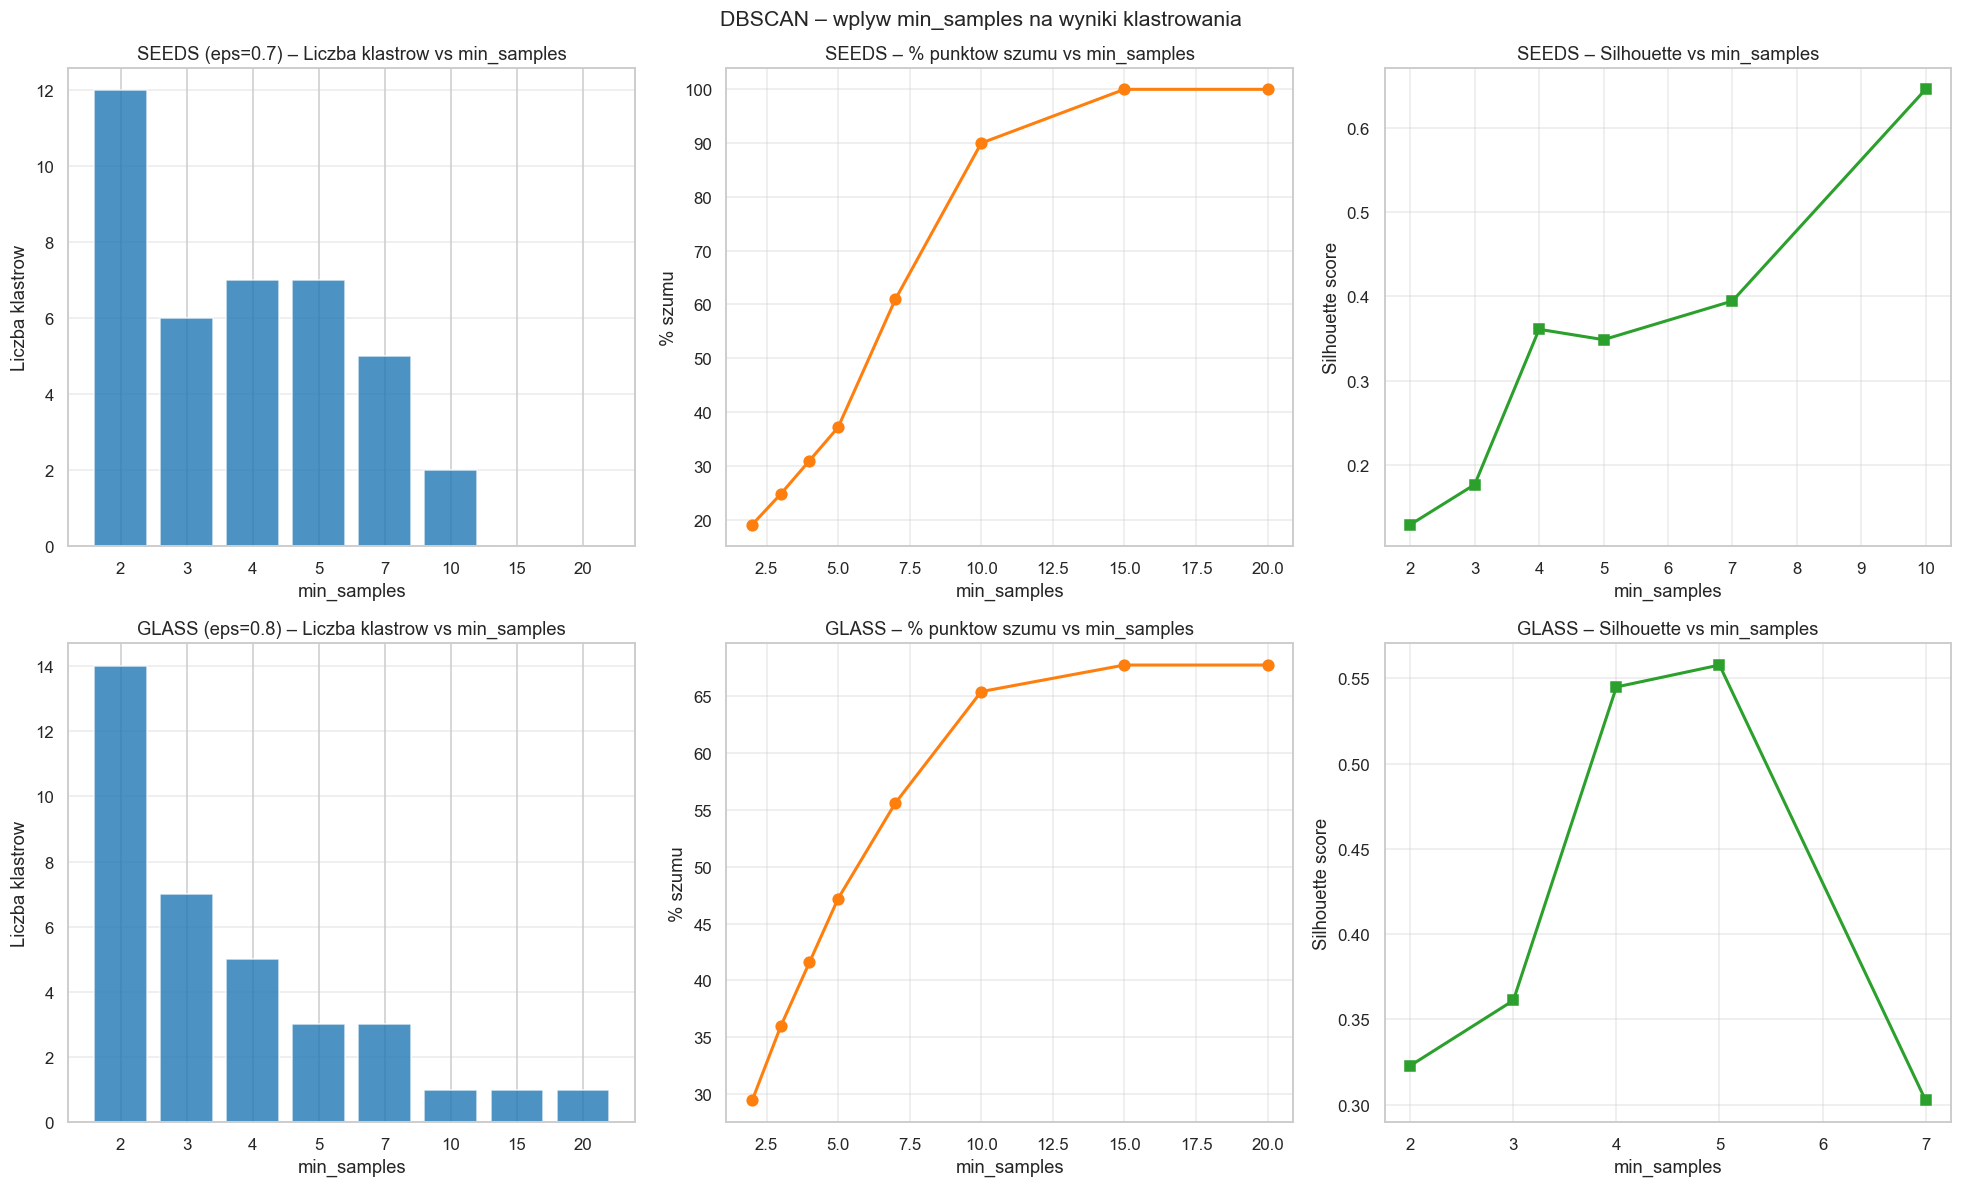

In [23]:
ms_range = [2, 3, 4, 5, 7, 10, 15, 20]
eps_opt  = {'SEEDS': 0.7, 'GLASS': 0.8}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('DBSCAN – wplyw min_samples na wyniki klastrowania', fontsize=14)

for row, (ds_name, X, y) in enumerate([('SEEDS', X_seeds, y_seeds),
                                         ('GLASS', X_glass, y_glass)]):
    eps = eps_opt[ds_name]
    n_cl_l, noise_pct_l, sil_l = [], [], []

    for ms in ms_range:
        db     = DBSCAN(eps=eps, min_samples=ms).fit(X)
        labels = db.labels_
        n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
        mask   = labels != -1
        n_cl_l.append(n_cl)
        noise_pct_l.append(100 * (labels == -1).sum() / len(labels))
        if n_cl >= 2 and mask.sum() > n_cl:
            sil_l.append(silhouette_score(X[mask], labels[mask]))
        else:
            sil_l.append(np.nan)

    x_pos = range(len(ms_range))
    axes[row, 0].bar(x_pos, n_cl_l, color='C0', alpha=0.8, edgecolor='white')
    axes[row, 0].set_xticks(x_pos); axes[row, 0].set_xticklabels(ms_range)
    axes[row, 0].set_xlabel('min_samples'); axes[row, 0].set_ylabel('Liczba klastrow')
    axes[row, 0].set_title(f'{ds_name} (eps={eps}) – Liczba klastrow vs min_samples')
    axes[row, 0].grid(True, alpha=0.4, axis='y')

    axes[row, 1].plot(ms_range, noise_pct_l, 'o-', lw=2, color='C1', markersize=7)
    axes[row, 1].set_xlabel('min_samples'); axes[row, 1].set_ylabel('% szumu')
    axes[row, 1].set_title(f'{ds_name} – % punktow szumu vs min_samples')
    axes[row, 1].grid(True, alpha=0.4)

    axes[row, 2].plot(ms_range, sil_l, 's-', lw=2, color='C2', markersize=7)
    axes[row, 2].set_xlabel('min_samples'); axes[row, 2].set_ylabel('Silhouette score')
    axes[row, 2].set_title(f'{ds_name} – Silhouette vs min_samples')
    axes[row, 2].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### 3c – Wpływ `metric` (metryki odległości)

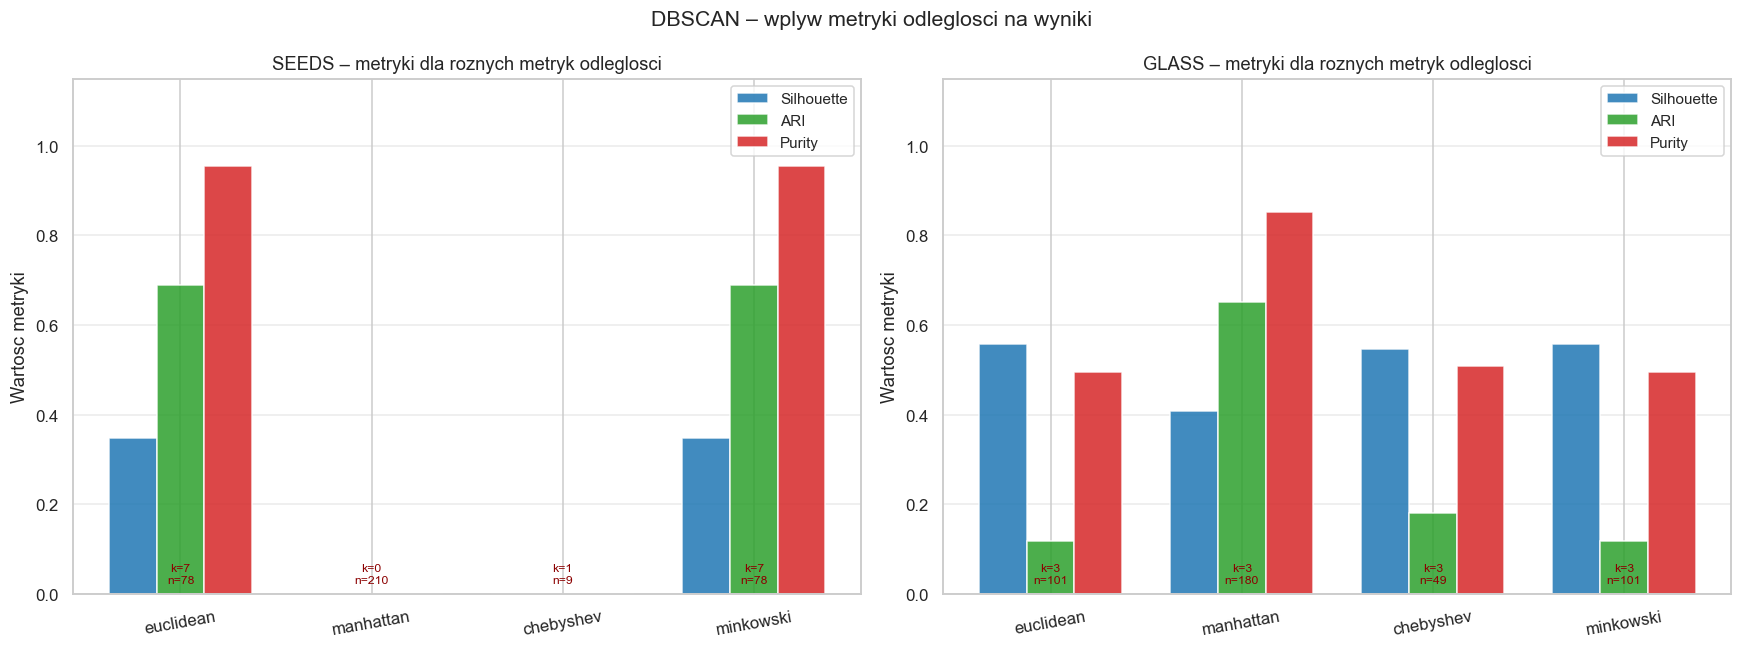

In [28]:
metrics_list = [
    ('euclidean', None),
    ('manhattan', None),
    ('chebyshev', None),
    ('minkowski', {'p': 2}),
]
eps_opt      = {'SEEDS': 0.7, 'GLASS': 0.8}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('DBSCAN – wplyw metryki odleglosci na wyniki', fontsize=14)

for ax, (ds_name, X, y) in zip(axes, [('SEEDS', X_seeds, y_seeds),
                                        ('GLASS', X_glass, y_glass)]):
    eps = eps_opt[ds_name]
    sil_v, ari_v, pur_v, ncl_v, noi_v = [], [], [], [], []

    for metric, metric_params in metrics_list:
        db     = DBSCAN(eps=eps, min_samples=5, metric=metric,
                        metric_params=metric_params or {}).fit(X)
        labels = db.labels_
        n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
        mask   = labels != -1
        ncl_v.append(n_cl); noi_v.append(int((labels == -1).sum()))
        if n_cl >= 2 and mask.sum() > n_cl:
            sil_v.append(silhouette_score(X[mask], labels[mask]))
            ari_v.append(adjusted_rand_score(y[mask], labels[mask]))
            pur_v.append(purity_score(y[mask], labels[mask]))
        else:
            sil_v.append(0); ari_v.append(0); pur_v.append(0)

    x      = np.arange(len(metrics_list))
    width  = 0.25
    ax.bar(x - width, sil_v, width, label='Silhouette',  color='C0', alpha=0.85)
    ax.bar(x,         ari_v, width, label='ARI',          color='C2', alpha=0.85)
    ax.bar(x + width, pur_v, width, label='Purity',       color='C3', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([m for m, _ in metrics_list], rotation=10)
    ax.set_ylabel('Wartosc metryki'); ax.set_ylim(0, 1.15)
    ax.set_title(f'{ds_name} – metryki dla roznych metryk odleglosci')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.4, axis='y')

    for i, (nc, nn) in enumerate(zip(ncl_v, noi_v)):
        ax.text(i, 0.02, f'k={nc}\nn={nn}',
                ha='center', va='bottom', fontsize=8, color='darkred')

plt.tight_layout()
plt.show()

### 3d – Siatka PCA 2D: różne konfiguracje (eps × min_samples)

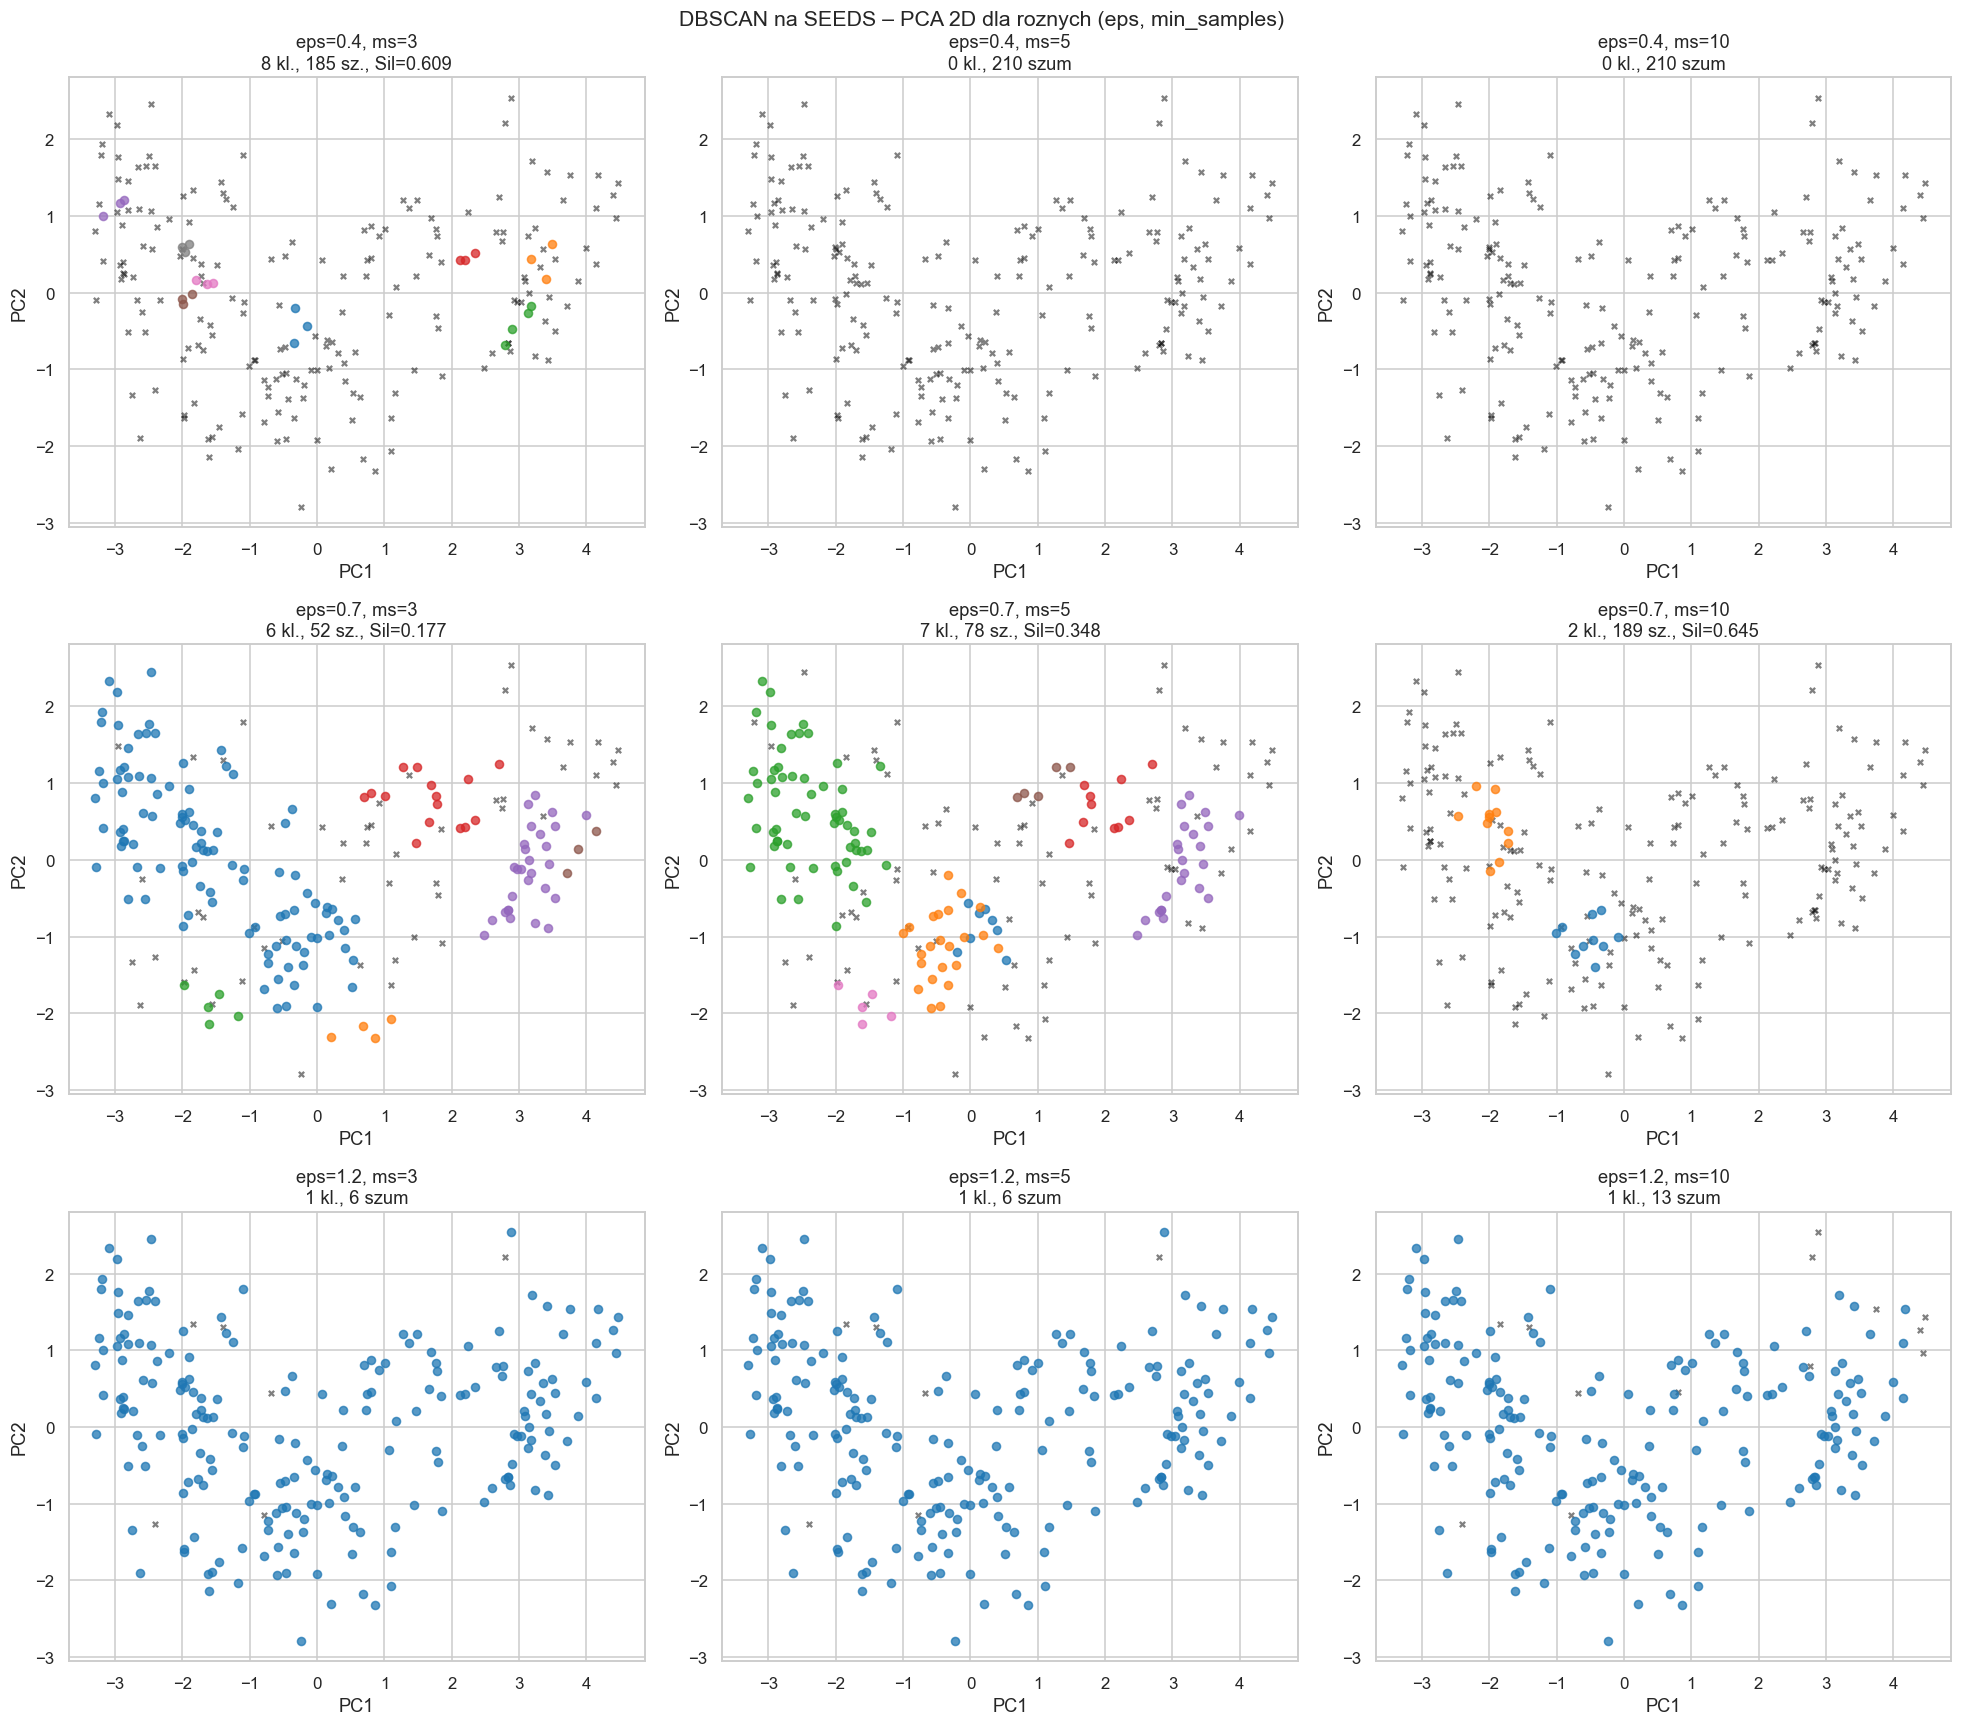

In [ ]:
eps_g = [0.4, 0.7, 1.2]
ms_g  = [3, 5, 10]

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle('DBSCAN na SEEDS – PCA 2D dla roznych (eps, min_samples)', fontsize=14)

X_s2d = pca_seeds.transform(X_seeds)

for row, eps in enumerate(eps_g):
    for col, ms in enumerate(ms_g):
        ax     = axes[row, col]
        db     = DBSCAN(eps=eps, min_samples=ms).fit(X_seeds)
        labels = db.labels_
        n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
        n_noi  = int((labels == -1).sum())
        pal    = sns.color_palette('tab10', max(n_cl, 1))
        ci     = 0
        for lbl in sorted(set(labels)):
            mask = labels == lbl
            if lbl == -1:
                ax.scatter(X_s2d[mask, 0], X_s2d[mask, 1],
                           c='black', s=12, marker='x', alpha=0.5)
            else:
                ax.scatter(X_s2d[mask, 0], X_s2d[mask, 1],
                           c=[pal[ci % 10]], s=28, alpha=0.75)
                ci += 1
        mask_v = labels != -1
        if n_cl >= 2 and mask_v.sum() > n_cl:
            sil = silhouette_score(X_seeds[mask_v], labels[mask_v])
            ax.set_title(f'eps={eps}, ms={ms}\n{n_cl} kl., {n_noi} sz., Sil={sil:.3f}')
        else:
            ax.set_title(f'eps={eps}, ms={ms}\n{n_cl} kl., {n_noi} szum')
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

### 3e – Metryki z etykietami + Per-sample Silhouette (DBSCAN)

SEEDS: ARI=0.689  Purity=0.955  Sil=0.348  DBI=0.966  Szum=37.1%
GLASS: ARI=0.118  Purity=0.496  Sil=0.558  DBI=0.476  Szum=47.2%


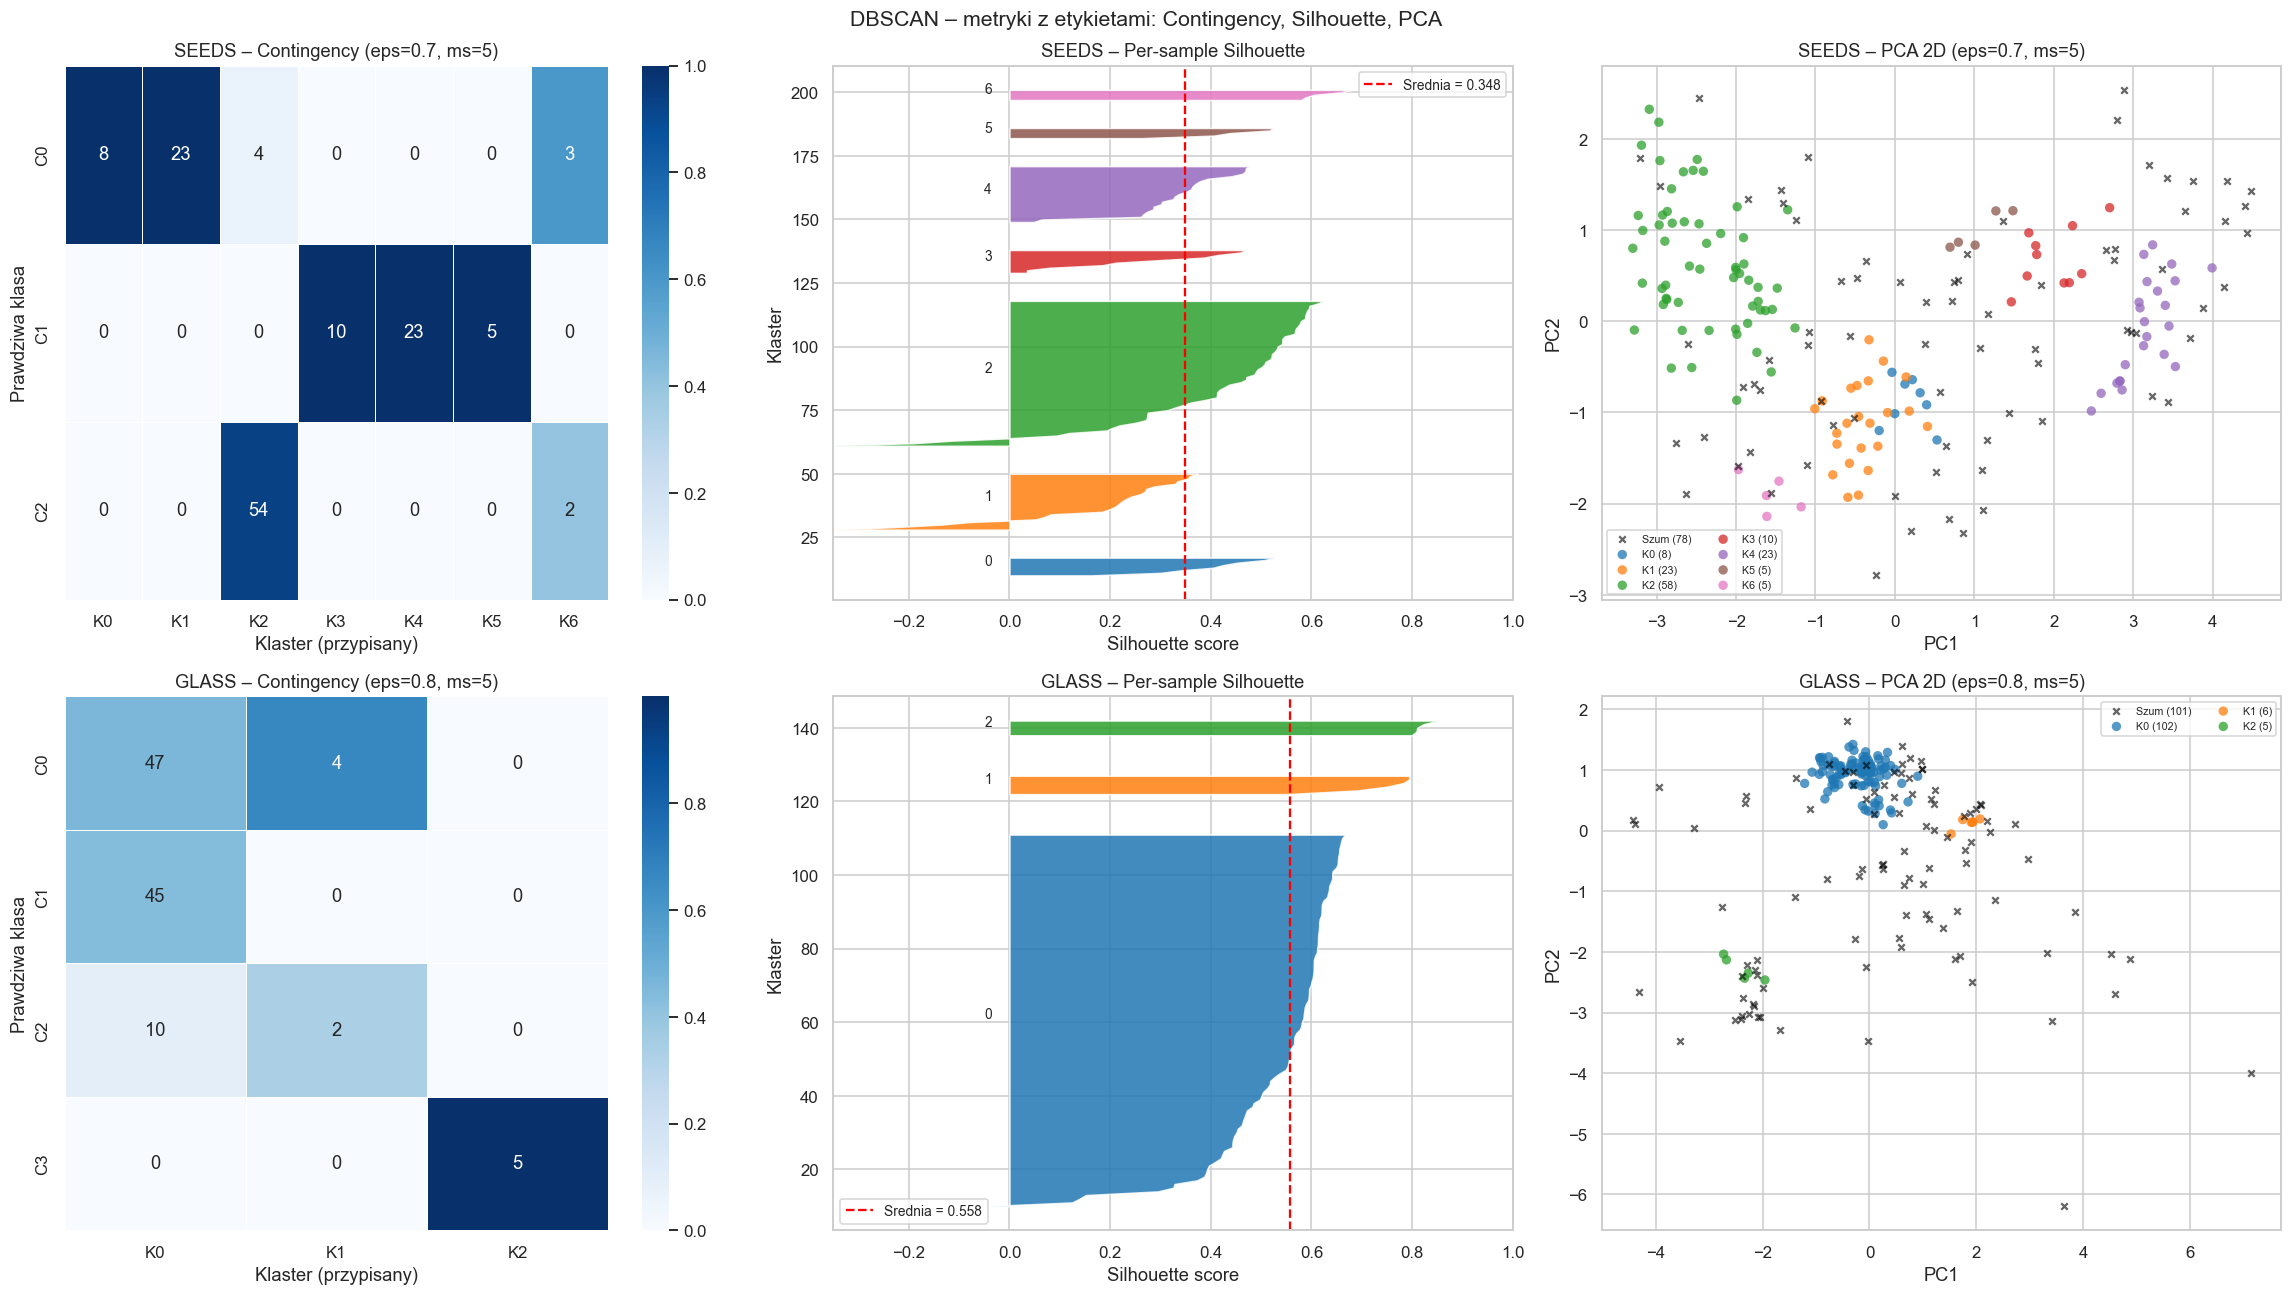

In [26]:
dbscan_best = {'SEEDS': (0.7, 5), 'GLASS': (0.8, 5)}

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
fig.suptitle('DBSCAN – metryki z etykietami: Contingency, Silhouette, PCA', fontsize=14)

for row, (ds_name, X, y) in enumerate([('SEEDS', X_seeds, y_seeds),
                                         ('GLASS', X_glass, y_glass)]):
    eps, ms  = dbscan_best[ds_name]
    db       = DBSCAN(eps=eps, min_samples=ms).fit(X)
    labels   = db.labels_
    mask     = labels != -1
    n_cl     = len(set(labels)) - (1 if -1 in labels else 0)
    pca_o    = pca_seeds if ds_name == 'SEEDS' else pca_glass

    # Contingency matrix
    if n_cl >= 1 and mask.sum() > 0:
        plot_contingency_heatmap(y[mask], labels[mask], axes[row, 0],
                                  title=f'{ds_name} – Contingency (eps={eps}, ms={ms})')

    # Per-sample Silhouette
    if n_cl >= 2 and mask.sum() > n_cl:
        plot_silhouette_diagram(X[mask], labels[mask], axes[row, 1],
                                 title=f'{ds_name} – Per-sample Silhouette')

    # PCA 2D
    plot_pca_clusters(X, labels, axes[row, 2], pca_o,
                      title=f'{ds_name} – PCA 2D (eps={eps}, ms={ms})')

    if n_cl >= 2 and mask.sum() > n_cl:
        ari_v = adjusted_rand_score(y[mask], labels[mask])
        pur_v = purity_score(y[mask], labels[mask])
        sil_v = silhouette_score(X[mask], labels[mask])
        dbi_v = davies_bouldin_score(X[mask], labels[mask])
        noi_p = 100 * (~mask).sum() / len(labels)
        print(f"{ds_name}: ARI={ari_v:.3f}  Purity={pur_v:.3f}  "
              f"Sil={sil_v:.3f}  DBI={dbi_v:.3f}  Szum={noi_p:.1f}%")

plt.tight_layout()
plt.show()

---
## Porownanie K-Means vs DBSCAN


In [27]:
# Najlepsze konfiguracje obu algorytmow
best_configs = {
    'SEEDS': {
        'K-Means': KMeans(n_clusters=3, n_init=20, random_state=SEED),
        'DBSCAN':  DBSCAN(eps=0.7, min_samples=5),
    },
    'GLASS': {
        'K-Means': KMeans(n_clusters=6, n_init=20, random_state=SEED),
        'DBSCAN':  DBSCAN(eps=0.8, min_samples=5),
    }
}

rows = []
for ds_name, X, y in [('SEEDS', X_seeds, y_seeds), ('GLASS', X_glass, y_glass)]:
    for alg_name, model in best_configs[ds_name].items():
        labels = model.fit_predict(X)
        mask   = labels != -1
        n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
        noi_p  = 100 * (labels == -1).sum() / len(labels)

        if n_cl >= 2 and mask.sum() > n_cl:
            sil = silhouette_score(X[mask], labels[mask])
            dbi = davies_bouldin_score(X[mask], labels[mask])
            ari = adjusted_rand_score(y[mask], labels[mask])
            pur = purity_score(y[mask], labels[mask])
        else:
            sil = dbi = ari = pur = np.nan

        rows.append({'Dataset': ds_name, 'Algorytm': alg_name,
                     'N klastrow': n_cl, 'Szum %': round(noi_p, 1),
                     'Silhouette': round(sil, 3), 'DBI': round(dbi, 3),
                     'ARI': round(ari, 3), 'Purity': round(pur, 3)})

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))

Dataset Algorytm  N klastrow  Szum %  Silhouette   DBI   ARI  Purity
  SEEDS  K-Means           3     0.0       0.401 0.928 0.773   0.919
  SEEDS   DBSCAN           7    37.1       0.348 0.966 0.689   0.955
  GLASS  K-Means           6     0.0       0.325 0.991 0.170   0.542
  GLASS   DBSCAN           3    47.2       0.558 0.476 0.118   0.496


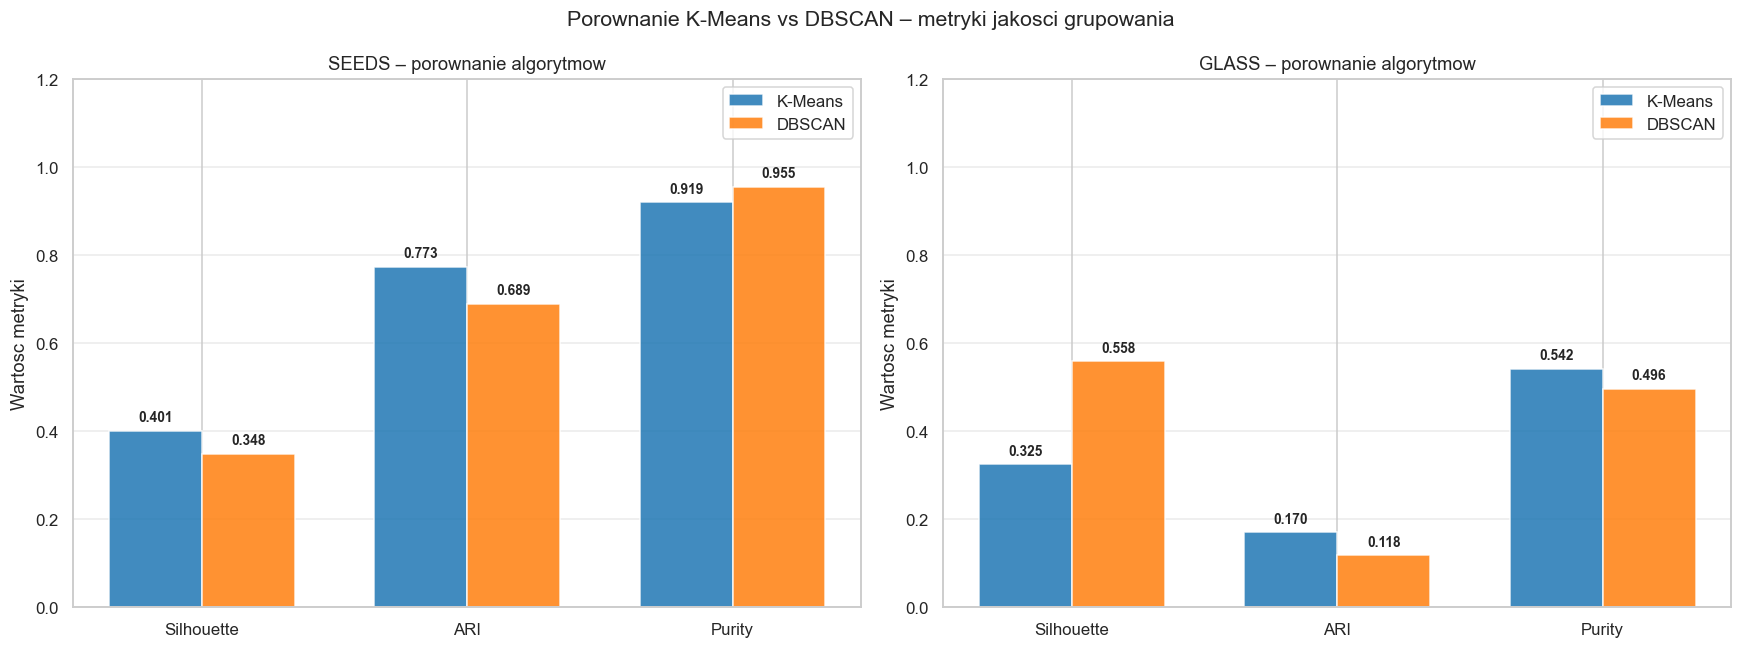

In [29]:
# Grouped bar chart – porownanie metryk
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Porownanie K-Means vs DBSCAN – metryki jakosci grupowania', fontsize=14)

metrics_cmp = ['Silhouette', 'ARI', 'Purity']

for ax, ds_name in zip(axes, ['SEEDS', 'GLASS']):
    df_ds  = df_summary[df_summary['Dataset'] == ds_name].reset_index(drop=True)
    x      = np.arange(len(metrics_cmp))
    width  = 0.35
    alg_names = df_ds['Algorytm'].tolist()

    for i, (_, row) in enumerate(df_ds.iterrows()):
        vals   = [row[m] for m in metrics_cmp]
        offset = (i - 0.5) * width
        bars   = ax.bar(x + offset, vals, width, label=alg_names[i],
                        color=f'C{i}', alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.015, f'{v:.3f}',
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(x); ax.set_xticklabels(metrics_cmp, fontsize=11)
    ax.set_ylabel('Wartosc metryki'); ax.set_ylim(0, 1.2)
    ax.set_title(f'{ds_name} – porownanie algorytmow')
    ax.legend(fontsize=11); ax.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

### PCA 2D: K-Means | DBSCAN | Ground Truth – wizualne porównanie

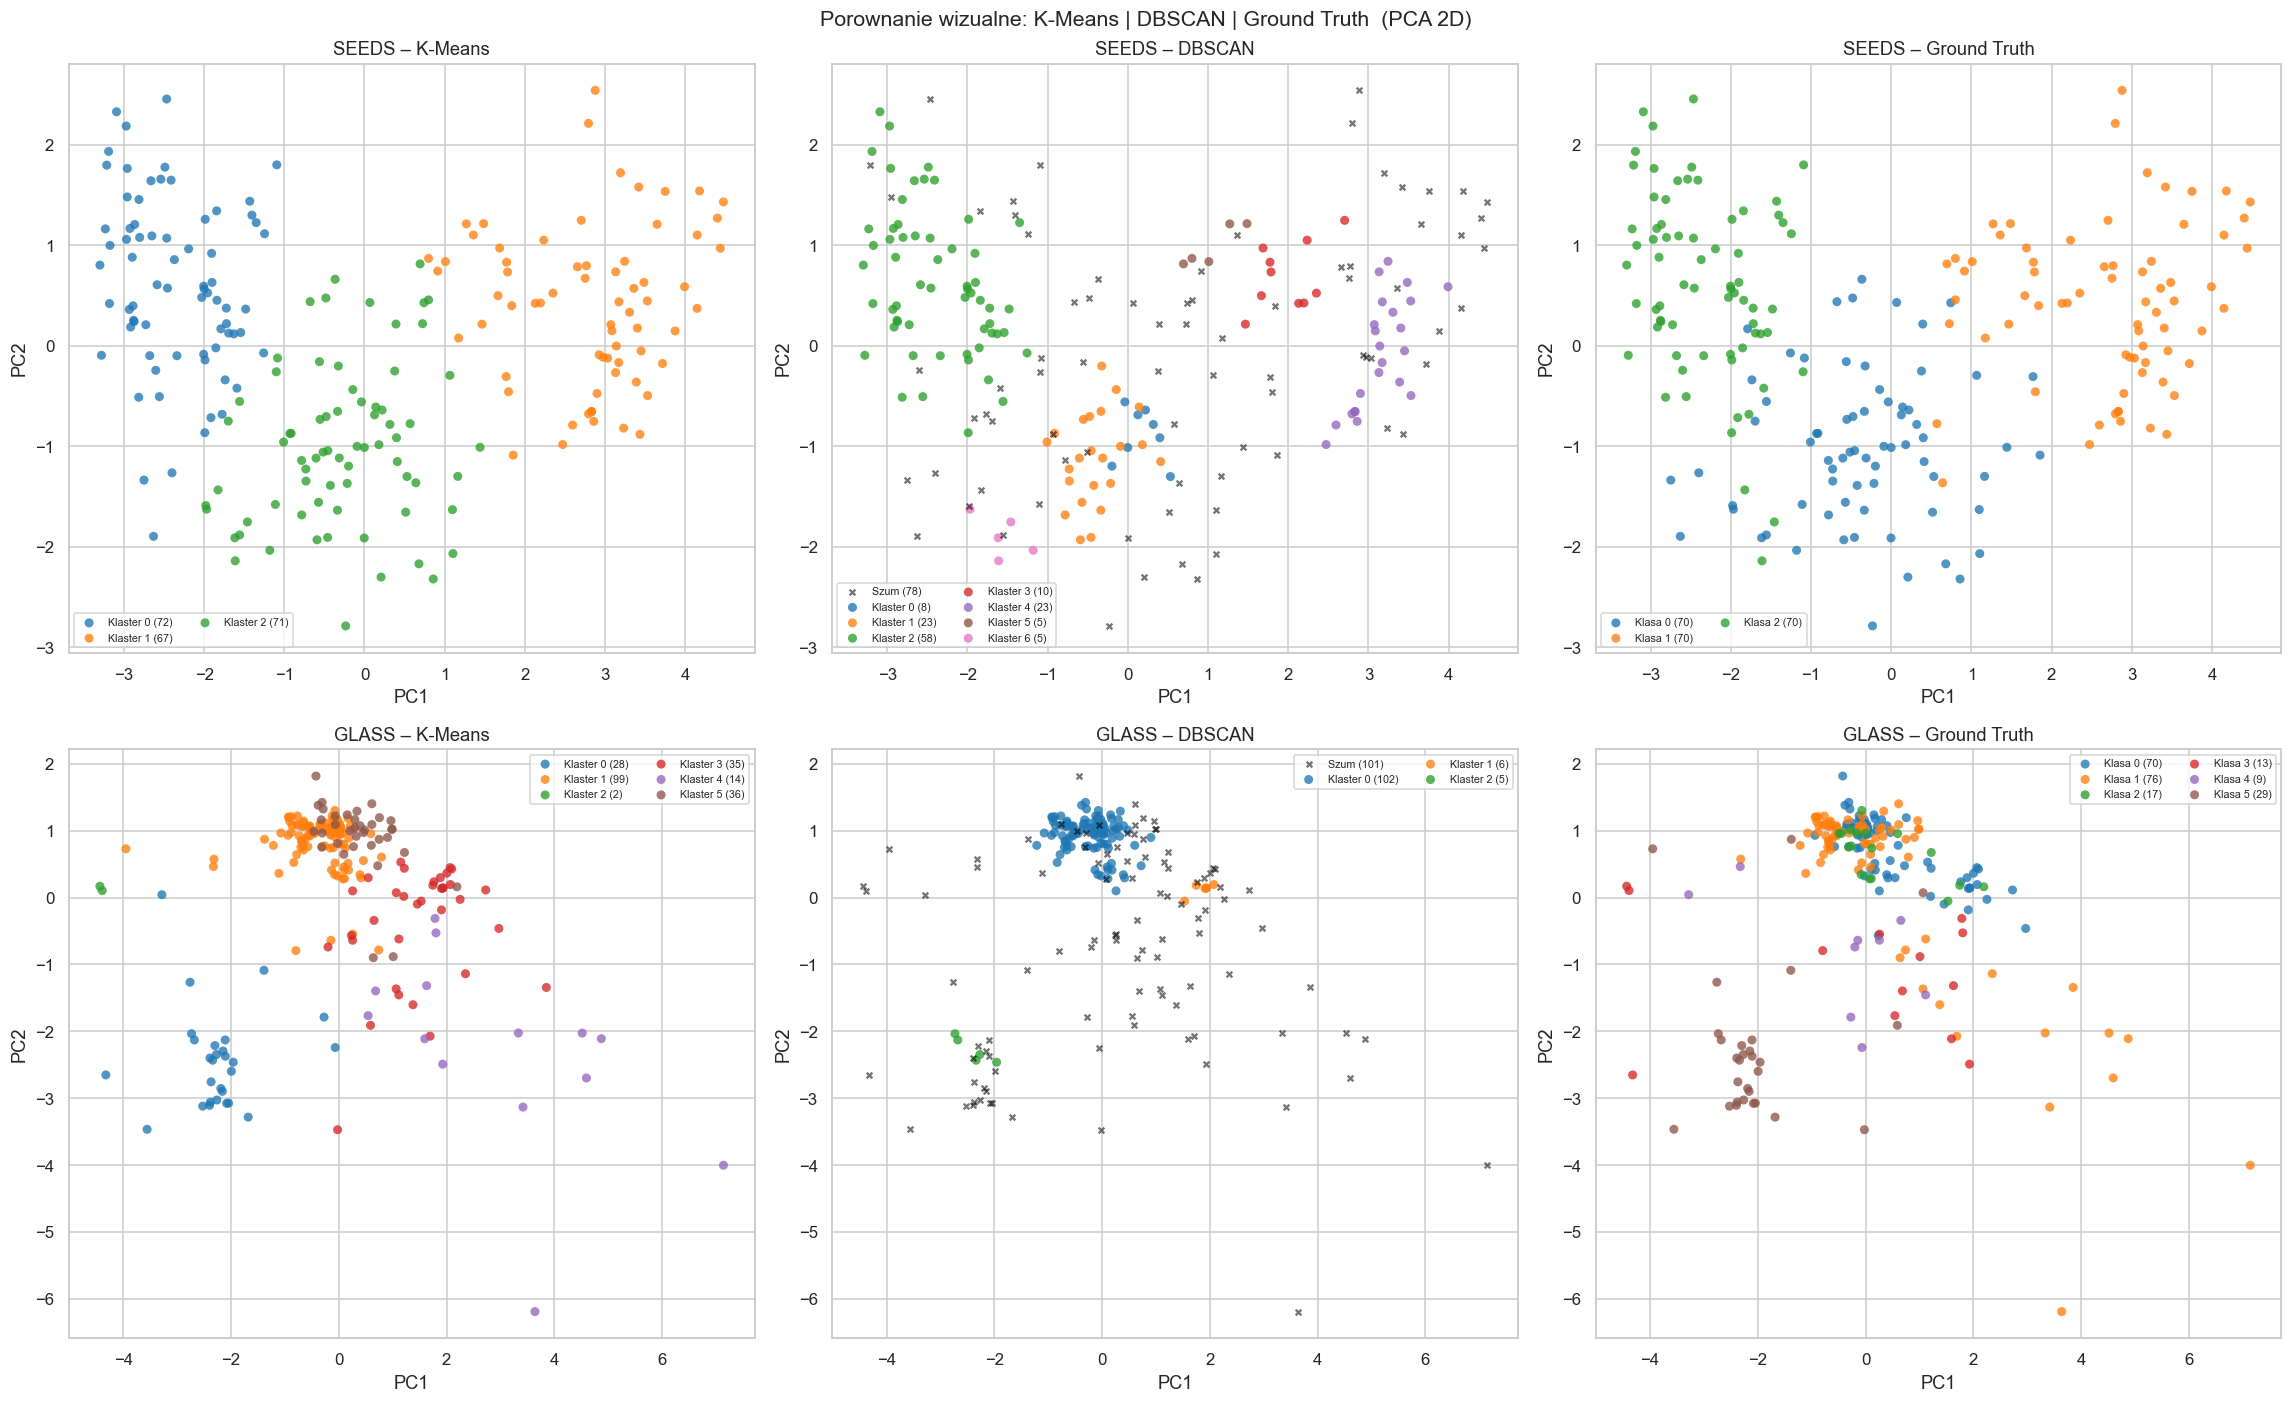

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(21, 13))
fig.suptitle('Porownanie wizualne: K-Means | DBSCAN | Ground Truth  (PCA 2D)', fontsize=14)

for row, (ds_name, X, y) in enumerate([('SEEDS', X_seeds, y_seeds),
                                         ('GLASS', X_glass, y_glass)]):
    pca_o    = pca_seeds if ds_name == 'SEEDS' else pca_glass
    X_2d     = pca_o.transform(X)
    labels_km = best_configs[ds_name]['K-Means'].fit_predict(X)
    labels_db = best_configs[ds_name]['DBSCAN'].fit_predict(X)

    titles_labels = [
        (labels_km, f'{ds_name} – K-Means'),
        (labels_db, f'{ds_name} – DBSCAN'),
        (y,         f'{ds_name} – Ground Truth'),
    ]
    for col, (labels, title) in enumerate(titles_labels):
        ax      = axes[row, col]
        u_lbls  = sorted(set(labels))
        n_real  = sum(1 for l in u_lbls if l != -1)
        pal     = sns.color_palette('tab10', max(n_real, 1))
        ci      = 0
        for lbl in u_lbls:
            mask   = labels == lbl
            lbl_s  = ('Klasa' if col == 2 else 'Klaster')
            if lbl == -1:
                ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                           c='black', s=14, marker='x', alpha=0.55,
                           label=f'Szum ({mask.sum()})', zorder=3)
            else:
                ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                           c=[pal[ci % 10]], s=35, alpha=0.78,
                           label=f'{lbl_s} {lbl} ({mask.sum()})', edgecolors='none')
                ci += 1
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
        ax.legend(fontsize=7, loc='best', ncol=2)

plt.tight_layout()
plt.show()

### Heatmapa zbiorcza wszystkich wyników

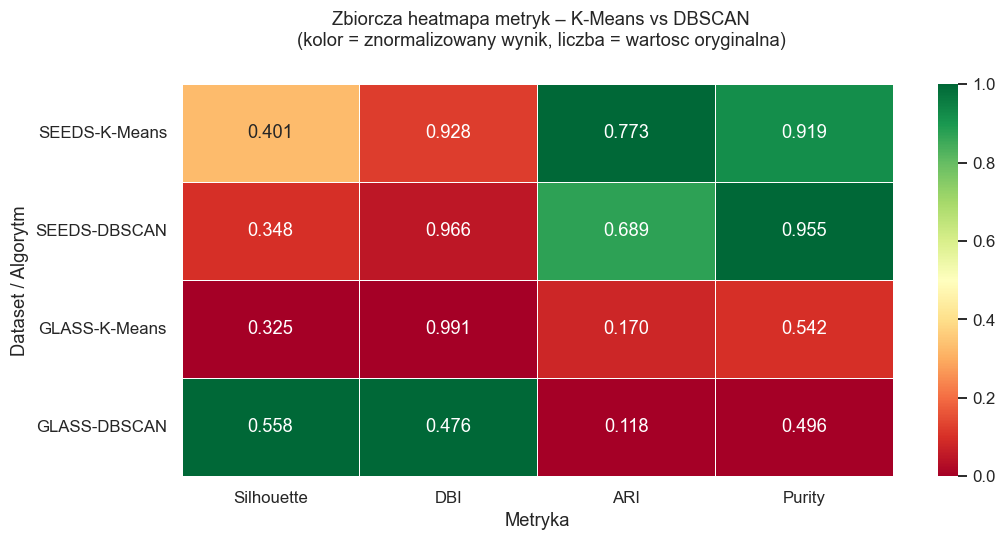

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Zbiorcza heatmapa metryk – K-Means vs DBSCAN\n'
             '(kolor = znormalizowany wynik, liczba = wartosc oryginalna)', fontsize=12)

pivot = df_summary.set_index(['Dataset', 'Algorytm'])[
    ['Silhouette', 'DBI', 'ARI', 'Purity']
].astype(float)

pivot_norm = pivot.copy()
for col in ['Silhouette', 'ARI', 'Purity']:   # wyzszy = lepszy
    mn, mx = pivot_norm[col].min(), pivot_norm[col].max()
    if mx > mn:
        pivot_norm[col] = (pivot_norm[col] - mn) / (mx - mn)
for col in ['DBI']:                             # nizszy = lepszy
    mn, mx = pivot_norm[col].min(), pivot_norm[col].max()
    if mx > mn:
        pivot_norm[col] = 1 - (pivot_norm[col] - mn) / (mx - mn)

sns.heatmap(pivot_norm, annot=pivot.round(3), fmt='.3f',
            cmap='RdYlGn', ax=ax, vmin=0, vmax=1,
            linewidths=0.6, linecolor='white')
ax.set_xlabel('Metryka'); ax.set_ylabel('Dataset / Algorytm')

plt.tight_layout()
plt.show()